# IE 517 Final Project


## Group Members

| Name         | NetID   | Email                 |
|--------------|---------|------------------------|
| Jiaqi Zeng   | jiaqi30 | jiaqi30@illinois.edu   |
| Cong Wang    | congw5  | congw5@illinois.edu    |
| Wenqi Guo    | wenqig2 | wenqig2@illinois.edu   |
| Ningqian Liu | nliu12  | nliu12@illinois.edu    |





# Introduction

Pricing American-style derivatives remains a fundamental yet computationally demanding problem in quantitative finance. Unlike their European counterparts, American options permit early exercise, resulting in a free-boundary problem whose value function exhibits strong nonlinearity with respect to strike, maturity, and especially volatility. Traditional numerical methods—such as tree-based algorithms, finite-difference schemes, or Monte Carlo regression (LSM)—provide accurate valuations but are often too slow for large-scale scenario generation, risk calculations, or real-time decision making.

Recent advances in machine learning suggest that neural networks can serve as surrogate pricers: after an offline training phase, a trained network can approximate the pricing function with orders-of-magnitude faster evaluation time. However, the effectiveness of neural networks in the American option setting—and how their performance varies across different volatility regimes and model assumptions—remains an open empirical question.

This project investigates volatility-aware neural network approximations for American put options under two widely used stochastic processes:

- **Black–Scholes model** (constant volatility)  
- **Heston model** (stochastic volatility)

To allow a unified comparison, we construct a common three-dimensional input space:

$$
(K,\, T, \sigma)
$$

where  
- $K$ is the strike,  
- $T$ is the maturity,  
- $\sigma$ is an effective volatility level.

For Black–Scholes, $\sigma$ is the usual constant volatility parameter.  

For the Heston model, the same volatility level is mapped into the variance parameters:
$$
v_0 = \sigma^2, \qquad \theta = \sigma^2
$$
so that both models share the same average volatility at each input point.  
This creates a fair basis for cross-model comparison and isolates the incremental effect of stochastic variance dynamics.

Using QuantLib finite-difference engines, we generate a dataset of American put prices:
$$
V_{\mathrm{BS}}(K,T,\sigma), \qquad V_{\mathrm{Heston}}(K,T,\sigma)
$$
which serve as ground-truth labels for supervised learning.

Two neural networks are then trained:

**$NN_{BS}$** approximating $V_{\mathrm{BS}}(K,T,\sigma)$.

**$NN_{Heston}$** approximating$V_{\mathrm{Heston}}(K,T,\sigma)$.

This framework enables structured experiments along three major dimensions:

1. Learning difficulty along the volatility axis
2. Cross-model price differences at matched volatility  
3. Speed–accuracy trade-offs for BS vs Heston vs neural networks


---------------------------------


### Setup
Before training any neural network models, we first build the computational framework required to generate reliable option prices.
This includes defining the $(K,T,\sigma)$ input domain and implementing two numerical pricing engines—one for the Black–Scholes model and one for the Heston model.
By evaluating these engines across the input grid, we obtain the benchmark American put prices that will serve as ground-truth labels for supervised learning.

In [ ]:
# =========================================================
#  Pricing engines and dataset construction
# =========================================================

!pip install -q QuantLib-Python
import numpy as np
import QuantLib as ql

# ---------------------------------------------------------
# 1 Global settings and parameter ranges
# ---------------------------------------------------------

SEED = 42
np.random.seed(SEED)

# Underlying and rates
S0 = 100.0 # spot
r = 0.03 # risk-free rate
q = 0.00 # continuous dividend yield

# Grids for K, T, sigma
K_MIN, K_MAX, N_K = 60.0, 140.0, 21 # strike range
T_MIN, T_MAX, N_T = 0.25, 2.0, 10 # maturity range (in years)

# Volatility axis: we treat sigma as an input dimension
SIGMAS = [0.15, 0.20, 0.25, 0.30, 0.40] # representative vol levels

# Heston parameters (except v0 and theta, which depend on sigma)
HESTON_KAPPA = 2.0 # speed of mean reversion
HESTON_SIGMA_V = 0.30 # vol of vol
HESTON_RHO = -0.70 # correlation between spot and variance

# Finite-difference grid sizes
FD_T_GRID_BS = 100
FD_X_GRID_BS = 200
FD_T_GRID_HESTON = 100
FD_X_GRID_HESTON = 200
FD_V_GRID_HESTON = 50


# ---------------------------------------------------------
# 2 Helper: QuantLib date / term structures
# ---------------------------------------------------------

def build_market_structures(r, q):
    """
    Build basic QuantLib term structures for risk-free and dividend yields.
    We use flat curves for simplicity.
    """
    calendar = ql.NullCalendar()
    day_counter = ql.Actual365Fixed()

    # Evaluation date
    settlement_date = ql.Date.todaysDate()
    ql.Settings.instance().evaluationDate = settlement_date

    # Flat risk-free and dividend yield term structures
    risk_free_ts = ql.YieldTermStructureHandle(
        ql.FlatForward(settlement_date, r, day_counter)
    )
    dividend_ts = ql.YieldTermStructureHandle(
        ql.FlatForward(settlement_date, q, day_counter)
    )

    return calendar, day_counter, settlement_date, risk_free_ts, dividend_ts


# ---------------------------------------------------------
# 3 Black–Scholes American put via FdBlackScholesVanillaEngine
# ---------------------------------------------------------

def american_put_price_bs_fd(
    S0, K, r, q, sigma, T,
    t_grid=FD_T_GRID_BS,
    x_grid=FD_X_GRID_BS
):
    """
    American put price under constant-vol Black–Scholes model,
    computed via QuantLib FdBlackScholesVanillaEngine.

    Parameters
    ----------
    S0 : float
        Spot price.
    K : float
        Strike.
    r : float
        Risk-free rate (cont. comp).
    q : float
        Dividend yield (cont. comp).
    sigma : float
        Constant volatility.
    T : float
        Time to maturity in years.
    t_grid : int
        Number of time steps in FD engine.
    x_grid : int
        Number of space steps in FD engine.

    Returns
    -------
    float
        American put price.
    """
    # Market structures
    calendar, day_counter, settlement_date, risk_free_ts, dividend_ts = build_market_structures(r, q)

    # Maturity date
    maturity_date = settlement_date + int(365 * T)

    # Spot and volatility
    spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))
    vol_ts = ql.BlackVolTermStructureHandle(
        ql.BlackConstantVol(settlement_date, calendar, sigma, day_counter)
    )

    # Black–Scholes-Merton process
    process = ql.BlackScholesMertonProcess(
        spot_handle, dividend_ts, risk_free_ts, vol_ts
    )

    # American put payoff and exercise
    payoff = ql.PlainVanillaPayoff(ql.Option.Put, K)
    exercise = ql.AmericanExercise(settlement_date, maturity_date)
    option = ql.VanillaOption(payoff, exercise)

    # FD engine for American options
    engine = ql.FdBlackScholesVanillaEngine(process, t_grid, x_grid)
    option.setPricingEngine(engine)

    return option.NPV()


# ---------------------------------------------------------
# 4 Heston American put via FdHestonVanillaEngine
# ---------------------------------------------------------

def american_put_price_heston_fd(
    S0, K, r, q, sigma_eff, T,
    kappa = HESTON_KAPPA,
    sigma_v = HESTON_SIGMA_V,
    rho     = HESTON_RHO,
    t_grid = FD_T_GRID_HESTON,
    x_grid = FD_X_GRID_HESTON,
    v_grid = FD_V_GRID_HESTON
):
    """
    American put price under Heston stochastic volatility model,
    computed via QuantLib FdHestonVanillaEngine.

    We map the input 'sigma_eff' to both initial variance v0 and
    long-run variance theta, so that the average volatility level
    is roughly consistent with the corresponding Black–Scholes
    sigma used for comparison.

    Parameters
    ----------
    S0 : float
        Spot price.
    K : float
        Strike.
    r : float
        Risk-free rate.
    q : float
        Dividend yield.
    sigma_eff : float
        Effective volatility level used to define v0 and theta
        via v0 = theta = sigma_eff^2.
    T : float
        Time to maturity in years.
    kappa : float
        Speed of mean reversion of variance.
    sigma_v : float
        Volatility of variance (vol-of-vol).
    rho : float
        Correlation between spot and variance Brownian motions.
    t_grid, x_grid, v_grid : int
        FD engine grid parameters.

    Returns
    -------
    float
        American put price under the Heston model.
    """
    # Market structures
    calendar, day_counter, settlement_date, risk_free_ts, dividend_ts = build_market_structures(r, q)

    # Maturity date
    maturity_date = settlement_date + int(365 * T)

    # Spot handle
    spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))

    # Map sigma_eff to Heston variance parameters
    v0 = sigma_eff ** 2 # initial variance
    theta = sigma_eff ** 2 # long-run variance

    # Heston process and model
    heston_process = ql.HestonProcess(
        risk_free_ts,
        dividend_ts,
        spot_handle,
        v0,
        kappa,
        theta,
        sigma_v,
        rho
    )
    heston_model = ql.HestonModel(heston_process)

    # American put payoff and exercise
    payoff = ql.PlainVanillaPayoff(ql.Option.Put, K)
    exercise = ql.AmericanExercise(settlement_date, maturity_date)
    option = ql.VanillaOption(payoff, exercise)

    # FdHestonVanillaEngine for American options
    engine = ql.FdHestonVanillaEngine(heston_model, t_grid, x_grid, v_grid)
    option.setPricingEngine(engine)

    return option.NPV()


# ---------------------------------------------------------
# 5 Build joint dataset: (K, T, sigma) -> prices under BS & Heston
# ---------------------------------------------------------

def build_joint_dataset(
    K_min=K_MIN, K_max=K_MAX, n_K=N_K,
    T_min=T_MIN, T_max=T_MAX, n_T=N_T,
    sigmas=SIGMAS
):
    """
    Build a dataset on (K, T, sigma) for both Black–Scholes and Heston
    American put prices.

    Returns
    -------
    X : ndarray, shape (N, 3)
        Input features [K, T, sigma].
    y_bs : ndarray, shape (N, 1)
        Black–Scholes American put prices.
    y_heston : ndarray, shape (N, 1)
        Heston American put prices.
    K_grid, T_grid, sigma_list : arrays
        Grids for visualization / slicing.
    """
    K_grid = np.linspace(K_min, K_max, n_K)
    T_grid = np.linspace(T_min, T_max, n_T)
    sigma_list = np.array(sigmas, dtype=float)

    X_list = []
    y_bs_list = []
    y_heston_list = []

    for sigma in sigma_list:
        print(f"Generating prices for sigma = {sigma:.3f}")
        for T in T_grid:
            for K in K_grid:
                # Black–Scholes American put
                price_bs = american_put_price_bs_fd(
                    S0, K, r, q, sigma, T
                )

                # Heston American put (sigma mapped to variance level)
                price_heston = american_put_price_heston_fd(
                    S0, K, r, q, sigma, T
                )

                X_list.append([K, T, sigma])
                y_bs_list.append(price_bs)
                y_heston_list.append(price_heston)

    X = np.array(X_list) # (N, 3)
    y_bs = np.array(y_bs_list).reshape(-1, 1) # (N, 1)
    y_heston = np.array(y_heston_list).reshape(-1, 1) # (N, 1)

    return X, y_bs, y_heston, K_grid, T_grid, sigma_list


# Actually build the dataset for Stage 0
X_raw, y_bs_raw, y_heston_raw, K_grid, T_grid, sigma_list = build_joint_dataset()

print("X_raw shape:", X_raw.shape)
print("y_bs_raw shape:", y_bs_raw.shape)
print("y_heston_raw shape:", y_heston_raw.shape)
print("K_grid:", K_grid)
print("T_grid:", T_grid)
print("sigma_list:", sigma_list)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 33.3 MB/s eta 0:00:00
Generating prices for sigma = 0.150
Generating prices for sigma = 0.200
Generating prices for sigma = 0.250
Generating prices for sigma = 0.300
Generating prices for sigma = 0.400
X_raw shape: (1050, 3)
y_bs_raw shape: (1050, 1)
y_heston_raw shape: (1050, 1)
K_grid: [ 60.  64.  68.  72.  76.  80.  84.  88.  92.  96. 100. 104. 108. 112.
 116. 120. 124. 128. 132. 136. 140.]
T_grid: [0.25       0.44444444 0.63888889 0.83333333 1.02777778 1.22222222
 1.41666667 1.61111111 1.80555556 2.        ]
sigma_list: [0.15 0.2  0.25 0.3  0.4 ]


------------------------------------------
## Stage 1 Scalar volatility

##Black-Scholes & Heston Comparison experiment

Having generated benchmark American put prices under both Black–Scholes and Heston models on a unified \((K, T, \sigma)\) domain, we now train volatility-aware neural network surrogate pricers. Each network takes the triple \((K, T, \sigma)\) as input and learns to approximate one of the two pricing engines:

- **NN\(_{\mathrm{BS}}\)** for \(V_{\mathrm{BS}}(K,T,\sigma)\)
- **NN\(_{\mathrm{Heston}}\)** for \(V_{\mathrm{Heston}}(K,T,\sigma)\)

To ensure stable training and meaningful comparisons, we standardize the input features, perform a train–test split, and use identical fully connected architectures for both models. The resulting networks will later be used to study approximation errors across volatility regimes and to compare constant-volatility and stochastic-volatility pricing behavior.


In [ ]:
# =========================================================
# 1 Volatility-aware neural network surrogate models
# =========================================================

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------------------------------------
# 1.1 Feature scaling and train/test split
# ---------------------------------------------------------

# Convert raw numpy arrays to float64 for stable statistics
X_np = X_raw.astype(np.float32) # shape (N, 3)
y_bs_np = y_bs_raw.astype(np.float32) # shape (N, 1)
y_heston_np = y_heston_raw.astype(np.float32) # shape (N, 1)

# Standardize inputs: (K, T, sigma) -> zero mean, unit variance
X_mean = X_np.mean(axis=0, keepdims=True)
X_std = X_np.std(axis=0, keepdims=True) + 1e-8  # avoid division by zero

X_scaled = (X_np - X_mean) / X_std

print("X_mean:", X_mean)
print("X_std:", X_std)

# Train/test split (same split for BS and Heston to keep them aligned)
X_train, X_test, y_bs_train, y_bs_test, y_heston_train, y_heston_test = train_test_split(
    X_scaled, y_bs_np, y_heston_np, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


# ---------------------------------------------------------
# 1.2 PyTorch datasets and loaders
# ---------------------------------------------------------

batch_size = 64

train_dataset_bs = TensorDataset(
    torch.from_numpy(X_train), torch.from_numpy(y_bs_train)
)
train_dataset_heston = TensorDataset(
    torch.from_numpy(X_train), torch.from_numpy(y_heston_train)
)

test_tensor_X = torch.from_numpy(X_test)
test_tensor_y_bs = torch.from_numpy(y_bs_test)
test_tensor_y_heston = torch.from_numpy(y_heston_test)

train_loader_bs = DataLoader(train_dataset_bs, batch_size=batch_size, shuffle=True)
train_loader_heston = DataLoader(train_dataset_heston, batch_size=batch_size, shuffle=True)


# ---------------------------------------------------------
# 1.3 Neural network architecture
# ---------------------------------------------------------

class FCNN(nn.Module):
    """
    Simple fully-connected network for regression:
    Input:  (K, T, sigma) after standardization
    Output: American put price under a given model
    """
    def __init__(self, input_dim=3, hidden_dim=64, num_hidden_layers=3):
        super().__init__()
        layers = []

        # First hidden layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Additional hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(hidden_dim, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def create_model():
    model = FCNN(input_dim=3, hidden_dim=64, num_hidden_layers=3)
    return model.to(device)


# ---------------------------------------------------------
# 1.4 Generic training loop
# ---------------------------------------------------------

def train_model(model, train_loader, n_epochs=500, lr=1e-3, verbose=True):
    """
    Train a regression model using MSE loss and Adam optimizer.
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(1, n_epochs + 1):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * X_batch.size(0)

        epoch_loss /= len(train_loader.dataset)

        if verbose and (epoch % 50 == 0 or epoch == 1):
            print(f"Epoch {epoch:4d} | Train MSE: {epoch_loss:.6f}")

    return model


def evaluate_model(model, X_test, y_test, label=""):
    """
    Compute MAE and RMSE on the test set.
    """
    model.eval()
    with torch.no_grad():
        X_test_t = X_test.to(device)
        y_test_t = y_test.to(device)
        y_pred_t = model(X_test_t)

    y_true = y_test_t.cpu().numpy().reshape(-1)
    y_pred = y_pred_t.cpu().numpy().reshape(-1)

    mae = mean_absolute_error(y_true, y_pred)
    # Older sklearn may not support 'squared=False', so we take the square root manually.
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"[{label}] Test MAE : {mae:.6f}")
    print(f"[{label}] Test RMSE: {rmse:.6f}")

    return y_pred, mae, rmse



# ---------------------------------------------------------
# 1.5 Train NN_BS and NN_Heston
# ---------------------------------------------------------

# Model for Black–Scholes prices
model_bs = create_model()
print("\nTraining NN_BS (Black–Scholes surrogate)...")
model_bs = train_model(model_bs, train_loader_bs, n_epochs=500, lr=1e-3)

# Model for Heston prices
model_heston = create_model()
print("\nTraining NN_Heston (Heston surrogate)...")
model_heston = train_model(model_heston, train_loader_heston, n_epochs=500, lr=1e-3)

# ---------------------------------------------------------
# 1.6 Evaluate both models on the aligned test set
# ---------------------------------------------------------

print("\nEvaluating models on the test set...")
y_bs_pred, mae_bs, rmse_bs = evaluate_model(
    model_bs, test_tensor_X, test_tensor_y_bs, label="NN_BS"
)

y_heston_pred, mae_heston, rmse_heston = evaluate_model(
    model_heston, test_tensor_X, test_tensor_y_heston, label="NN_Heston"
)


Using device: cpu
X_mean: [[100.           1.1249976    0.25999933]]
X_std: [[24.221203    0.5584995   0.08602328]]
Train size: 840
Test size: 210

Training NN_BS (Black–Scholes surrogate)...
Epoch    1 | Train MSE: 368.614699
Epoch   50 | Train MSE: 0.106097
Epoch  100 | Train MSE: 0.020334
Epoch  150 | Train MSE: 0.010556
Epoch  200 | Train MSE: 0.007382
Epoch  250 | Train MSE: 0.005716
Epoch  300 | Train MSE: 0.003960
Epoch  350 | Train MSE: 0.004803
Epoch  400 | Train MSE: 0.003543
Epoch  450 | Train MSE: 0.009301
Epoch  500 | Train MSE: 0.002882

Training NN_Heston (Heston surrogate)...
Epoch    1 | Train MSE: 352.093323
Epoch   50 | Train MSE: 0.085258
Epoch  100 | Train MSE: 0.020053
Epoch  150 | Train MSE: 0.014108
Epoch  200 | Train MSE: 0.007862
Epoch  250 | Train MSE: 0.009159
Epoch  300 | Train MSE: 0.005127
Epoch  350 | Train MSE: 0.010141
Epoch  400 | Train MSE: 0.002835
Epoch  450 | Train MSE: 0.002456
Epoch  500 | Train MSE: 0.002874

Evaluating models on the test set..

### Experiment 1 - Volatility-wise learning difficulty


In [ ]:

# 2.1 Recover original (K, T, sigma) for the test set
# X_test is standardized; we invert the transformation
X_test_np = X_test # shape (N_test, 3), already a NumPy array from earlier
X_test_orig = X_test_np * X_std + X_mean # unscale back to original space

K_test = X_test_orig[:, 0]
T_test = X_test_orig[:, 1]
sigma_test = X_test_orig[:, 2]

print("Min / Max sigma in test set:", sigma_test.min(), sigma_test.max())

# 2.2 Build buckets for low, mid, high volatility
low_mask = (sigma_test >= 0.10) & (sigma_test <= 0.20)
mid_mask = (sigma_test >  0.20) & (sigma_test <= 0.35)
high_mask = (sigma_test >  0.35) & (sigma_test <= 0.50)

def bucket_stats(mask,
      y_true_bs, y_pred_bs,
      y_true_heston, y_pred_heston,
      name=""):
    """
    Compute MAE and RMSE in a given sigma bucket
    for both BS and Heston models.
    """
    idx = np.where(mask)[0]
    n = len(idx)
    if n == 0:
        print(f"[{name}] No test points in this bucket.")
        return

    y_bs_true_b = y_true_bs[idx]
    y_bs_pred_b = y_pred_bs[idx]
    y_heston_true_b = y_true_heston[idx]
    y_heston_pred_b = y_heston_pred[idx]

    mae_bs = mean_absolute_error(y_bs_true_b, y_bs_pred_b)
    rmse_bs = np.sqrt(mean_squared_error(y_bs_true_b, y_bs_pred_b))

    mae_h = mean_absolute_error(y_heston_true_b, y_heston_pred_b)
    rmse_h = np.sqrt(mean_squared_error(y_heston_true_b, y_heston_pred_b))

    print(f"\n[{name}] #points = {n}")
    print(f"BS - MAE: {mae_bs:.6f}, RMSE: {rmse_bs:.6f}")
    print(f"Heston - MAE: {mae_h:.6f}, RMSE: {rmse_h:.6f}")


# 2.3 Prepare true / predicted arrays for the test set

# These were already computed in evaluate_model; we just reuse them here.
# test_tensor_y_bs / test_tensor_y_heston are torch tensors; convert to NumPy.
y_bs_true_test = test_tensor_y_bs.numpy().reshape(-1)
y_heston_true_test = test_tensor_y_heston.numpy().reshape(-1)

# y_bs_pred / y_heston_pred are NumPy arrays from evaluate_model return
# (they already have shape (N_test,))
# Ensure they are 1D
y_bs_pred_flat = y_bs_pred.reshape(-1)
y_heston_pred_flat = y_heston_pred.reshape(-1)

# 2.4 Compute stats for each sigma bucket

bucket_stats(low_mask,
             y_bs_true_test, y_bs_pred_flat,
             y_heston_true_test, y_heston_pred_flat,
             name="Low volatility (sigma in [0.10, 0.20])")

bucket_stats(mid_mask,
             y_bs_true_test, y_bs_pred_flat,
             y_heston_true_test, y_heston_pred_flat,
             name="Medium volatility (sigma in (0.20, 0.35])")

bucket_stats(high_mask,
             y_bs_true_test, y_bs_pred_flat,
             y_heston_true_test, y_heston_pred_flat,
             name="High volatility (sigma in (0.35, 0.50])")


Min / Max sigma in test set: 0.15 0.4

[Low volatility (sigma in [0.10, 0.20])] #points = 88
BS - MAE: 0.044817, RMSE: 0.060650
Heston - MAE: 0.045886, RMSE: 0.064506

[Medium volatility (sigma in (0.20, 0.35])] #points = 80
BS - MAE: 0.071991, RMSE: 0.091837
Heston - MAE: 0.058146, RMSE: 0.078729

[High volatility (sigma in (0.35, 0.50])] #points = 42
BS - MAE: 0.048607, RMSE: 0.060907
Heston - MAE: 0.079429, RMSE: 0.108748


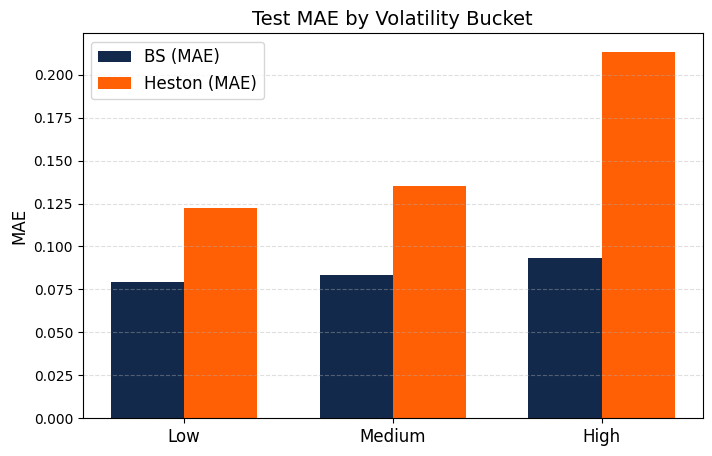

In [ ]:
import matplotlib.pyplot as plt

# Volatility buckets
buckets = ["Low", "Medium", "High"]

# MAE values
mae_bs = [0.079368, 0.083361, 0.093295]
mae_h  = [0.122259, 0.134985, 0.213406]

x = np.arange(len(buckets))
width = 0.35

plt.figure(figsize=(8,5))

# Illini official colors
illini_orange = "#FF5F05"
illini_blue = "#13294B"

plt.bar(x - width/2, mae_bs, width, label="BS (MAE)", color=illini_blue)
plt.bar(x + width/2, mae_h,  width, label="Heston (MAE)", color=illini_orange)

plt.xticks(x, buckets, fontsize=12)
plt.ylabel("MAE", fontsize=12)
plt.title("Test MAE by Volatility Bucket", fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


### Experiment 2 – Price surfaces and model differences between Black–Scholes and Heston models with the same sigma

This experiment analyzes how Black–Scholes and Heston American put prices differ when both models are evaluated on the same (K, T, sigma) domain. Rather than focusing on absolute pricing accuracy, the goal here is to understand the structural gap between the two models and to check whether this cross–model difference can be reproduced by the neural networks.

We compute the price difference

Delta_V(K, T, sigma) = V_Heston(K, T, sigma) – V_BS(K, T, sigma)

on the full pricing grid and on the test set. Because both models use the same effective volatility level (with v0 = theta = sigma^2 in the Heston specification), the sign and magnitude of Delta_V directly reflect differences coming from stochastic variance dynamics rather than from differences in volatility levels.

We visualize this difference in several ways:

1. For fixed volatility levels (sigma = 0.20, 0.30, 0.40), we plot heatmaps of Delta_V(K, T).  
2. We compute the neural-network analogue Delta_V_hat and compare its surface with the true Delta_V to assess whether the networks learn the model gap.  
3. Finally, we plot one–dimensional slices of Delta_V and Delta_V_hat as functions of maturity for both an at–the–money strike and a deep in–the–money strike. These slices highlight that the sign and magnitude of the model difference vary systematically with sigma, maturity, and moneyness.

This experiment provides additional insight into where the two pricing models diverge and whether neural networks are capable of reproducing these structural differences.


In [ ]:
# =========================================================
# Numerical analysis of ΔV on the test set
# ΔV_true = V_Heston - V_BS
# ΔV_hat  = V_hat_Heston - V_hat_BS
# =========================================================

# 1) Recover original (K, T, sigma) for the test set
X_test_np = X_test # shape (N_test, 3), standardized
X_test_orig = X_test_np * X_std + X_mean # unscale back to original space

K_test = X_test_orig[:, 0]
T_test = X_test_orig[:, 1]
sigma_test = X_test_orig[:, 2]

print("Test set sigma range:", sigma_test.min(), "to", sigma_test.max())

# 2) True BS and Heston prices on the test set
y_bs_true_test = y_bs_test.reshape(-1)
y_heston_true_test = y_heston_test.reshape(-1)

# 3) NN-predicted BS and Heston prices on the test set
model_bs.eval()
model_heston.eval()

with torch.no_grad():
    X_test_t = torch.from_numpy(X_test_np.astype(np.float32)).to(device)
    y_bs_pred_t = model_bs(X_test_t)
    y_heston_pred_t = model_heston(X_test_t)

y_bs_pred = y_bs_pred_t.cpu().numpy().reshape(-1)
y_heston_pred = y_heston_pred_t.cpu().numpy().reshape(-1)

# 4) Compute ΔV_true and ΔV_hat
delta_true = y_heston_true_test - y_bs_true_test
delta_hat = y_heston_pred - y_bs_pred

# 5) Overall statistics
mae_delta = mean_absolute_error(delta_true, delta_hat)
rmse_delta = np.sqrt(mean_squared_error(delta_true, delta_hat))

print("\n=== Overall ΔV statistics on the test set ===")
print(f"Number of test points: {len(delta_true)}")
print(f"Mean ΔV_true: {delta_true.mean():.6f}")
print(f"Min ΔV_true: {delta_true.min():.6f}")
print(f"Max ΔV_true: {delta_true.max():.6f}")
print(f"Mean |ΔV_hat - ΔV_true|: {mae_delta:.6f}")
print(f"RMSE(ΔV_hat, ΔV_true):  {rmse_delta:.6f}")

# 6) Bucketed analysis by volatility (same buckets as Experiment 1)
low_mask = (sigma_test >= 0.10) & (sigma_test <= 0.20)
mid_mask = (sigma_test > 0.20) & (sigma_test <= 0.35)
high_mask = (sigma_test > 0.35) & (sigma_test <= 0.50)

def bucket_delta_stats(mask, name=""):
    idx = np.where(mask)[0]
    n = len(idx)
    if n == 0:
        print(f"\n[{name}] No points in this bucket.")
        return

    d_true_b = delta_true[idx]
    d_hat_b = delta_hat[idx]

    mae_b = mean_absolute_error(d_true_b, d_hat_b)
    rmse_b = np.sqrt(mean_squared_error(d_true_b, d_hat_b))

    print(f"\n[{name}] #points = {n}")
    print(f"  Mean ΔV_true: {d_true_b.mean():.6f}")
    print(f"  Min  ΔV_true: {d_true_b.min():.6f}")
    print(f"  Max  ΔV_true: {d_true_b.max():.6f}")
    print(f"  MAE(ΔV_hat, ΔV_true):  {mae_b:.6f}")
    print(f"  RMSE(ΔV_hat, ΔV_true): {rmse_b:.6f}")

bucket_delta_stats(low_mask,  "Low volatility (sigma in [0.10, 0.20])")
bucket_delta_stats(mid_mask,  "Medium volatility (sigma in (0.20, 0.35])")
bucket_delta_stats(high_mask, "High volatility (sigma in (0.35, 0.50])")


Test set sigma range: 0.15 to 0.4

=== Overall ΔV statistics on the test set ===
Number of test points: 210
Mean ΔV_true: -0.097632
Min ΔV_true: -1.082760
Max ΔV_true: 0.580211
Mean |ΔV_hat - ΔV_true|: 0.076348
RMSE(ΔV_hat, ΔV_true):  0.103739

[Low volatility (sigma in [0.10, 0.20])] #points = 88
  Mean ΔV_true: -0.044551
  Min  ΔV_true: -0.773489
  Max  ΔV_true: 0.580211
  MAE(ΔV_hat, ΔV_true):  0.063048
  RMSE(ΔV_hat, ΔV_true): 0.087280

[Medium volatility (sigma in (0.20, 0.35])] #points = 80
  Mean ΔV_true: -0.037144
  Min  ΔV_true: -0.972633
  Max  ΔV_true: 0.540528
  MAE(ΔV_hat, ΔV_true):  0.091535
  RMSE(ΔV_hat, ΔV_true): 0.119424

[High volatility (sigma in (0.35, 0.50])] #points = 42
  Mean ΔV_true: -0.324063
  Min  ΔV_true: -1.082760
  Max  ΔV_true: 0.443938
  MAE(ΔV_hat, ΔV_true):  0.075287
  RMSE(ΔV_hat, ΔV_true): 0.103352


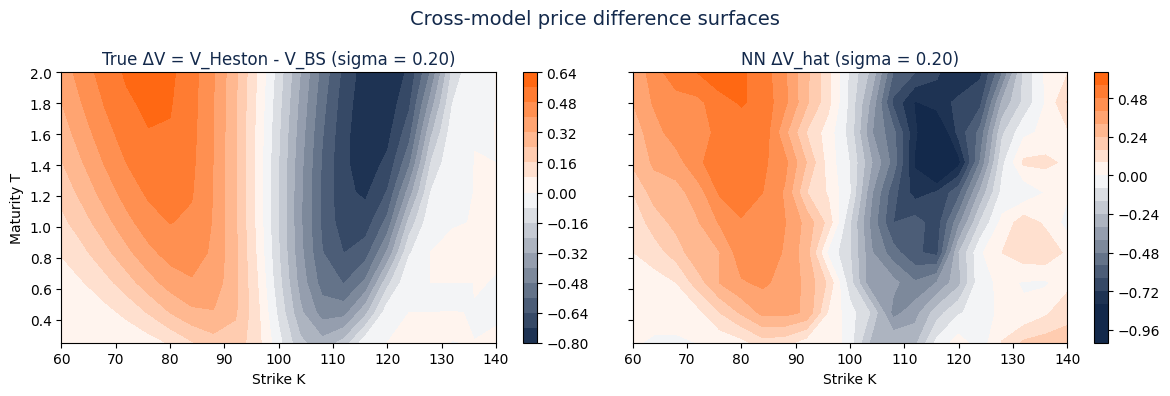

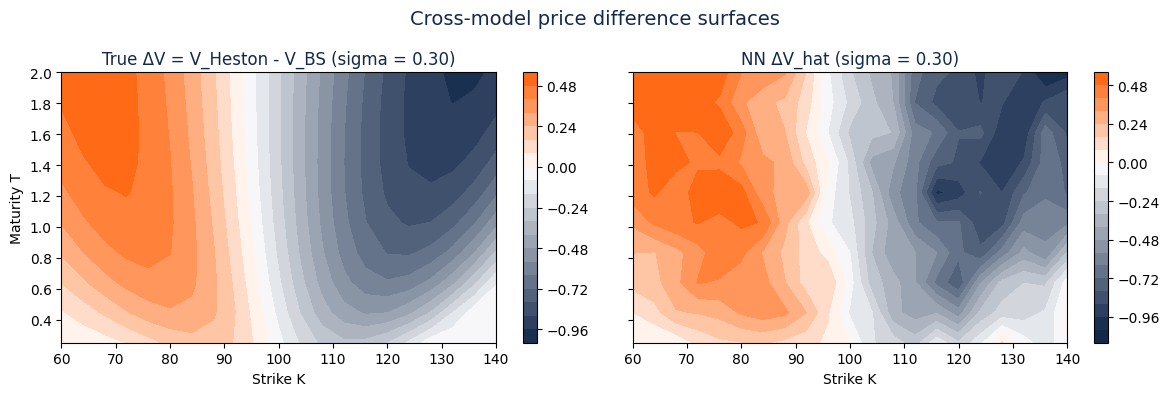

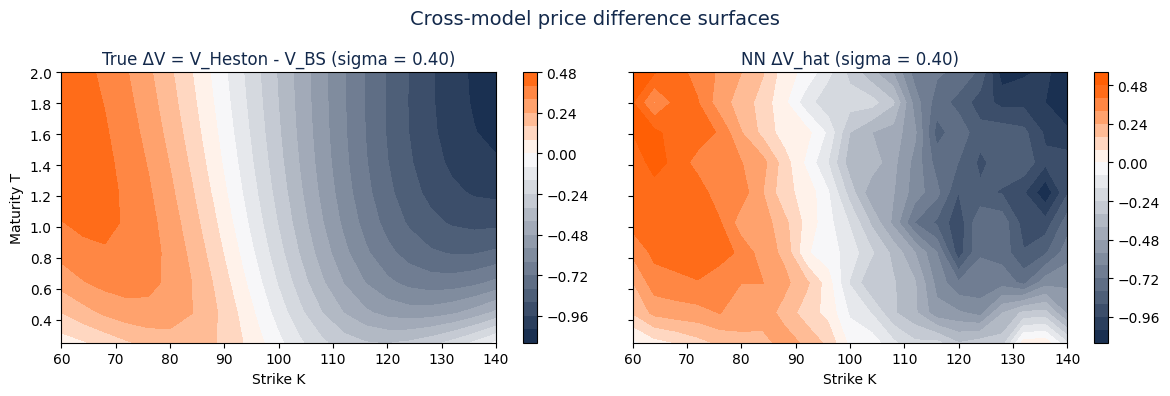

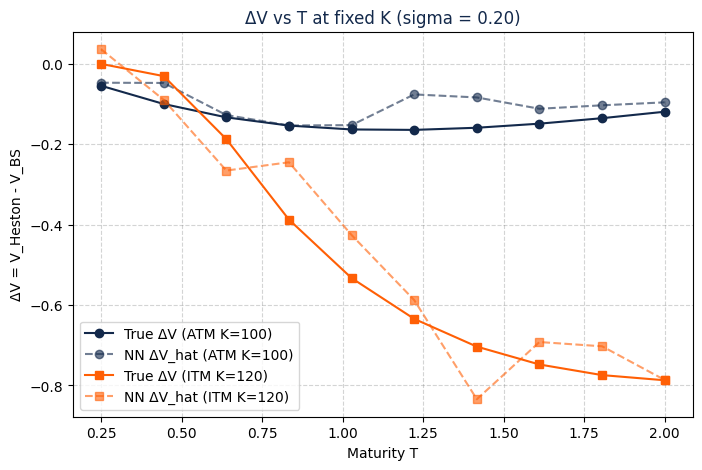

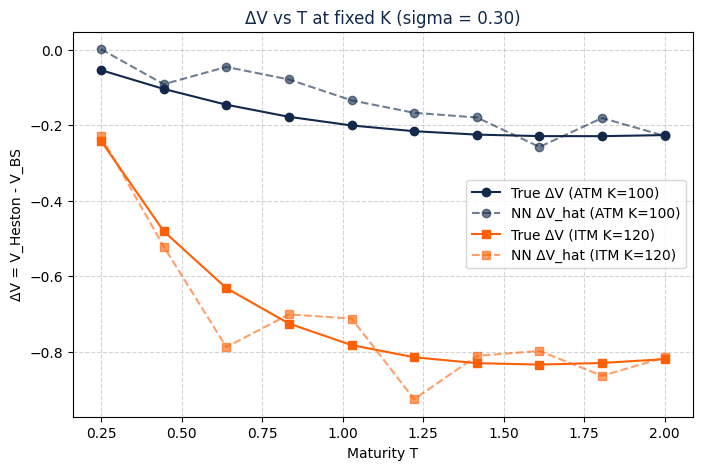

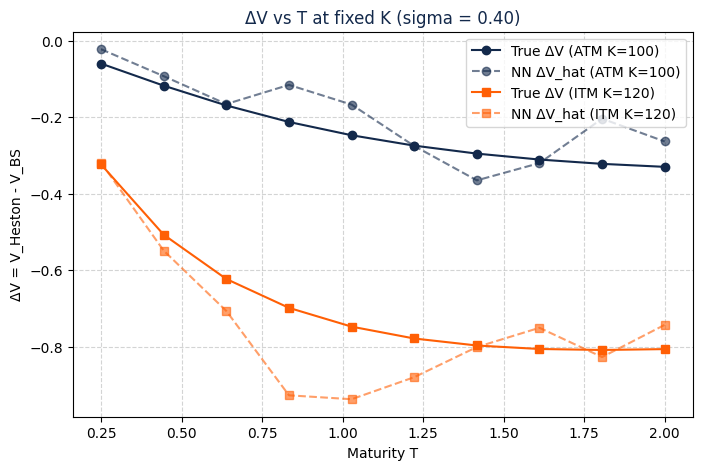

In [ ]:
# =========================================================
#  Visualization of ΔV surfaces and slices
# =========================================================
from matplotlib.colors import LinearSegmentedColormap
storm_gray    = "#707372"

# Colormap
illini_cmap = LinearSegmentedColormap.from_list(
    "illini_cmap", [illini_blue, "white", illini_orange]
)

# True BS/Heston surfaces on (K, T) grid for a fixed sigma
def get_true_surfaces_for_sigma(sigma_level):
    """
    Return BS and Heston price surfaces on the (K, T) grid
    for a given sigma_level, using the Stage 0 grid data.

    Output shapes:
        V_bs_true, V_heston_true: (n_T, n_K)
    """
    # X_raw: (N, 3) with columns [K, T, sigma]
    mask = np.isclose(X_raw[:, 2], sigma_level, atol=1e-6)
    if mask.sum() == 0:
        raise ValueError(f"No points found for sigma={sigma_level} in X_raw.")

    V_bs_sigma     = y_bs_raw[mask].reshape(len(T_grid), len(K_grid))
    V_heston_sigma = y_heston_raw[mask].reshape(len(T_grid), len(K_grid))

    return V_bs_sigma, V_heston_sigma


#  NN-predicted BS/Heston surfaces on (K, T) grid

def get_nn_surfaces_for_sigma(sigma_level, model_bs, model_heston):
    """
    Use the trained neural networks to approximate BS and Heston
    surfaces at a fixed sigma_level on the (K, T) grid.
    """
    KK, TT = np.meshgrid(K_grid, T_grid)  # (n_T, n_K)
    sigma_mat = np.full_like(KK, sigma_level, dtype=np.float32)

    X_sigma = np.stack([KK.ravel(), TT.ravel(), sigma_mat.ravel()], axis=1)
    X_sigma_scaled = (X_sigma - X_mean) / X_std
    X_sigma_scaled = X_sigma_scaled.astype(np.float32)

    X_tensor = torch.from_numpy(X_sigma_scaled).to(device)

    model_bs.eval()
    model_heston.eval()
    with torch.no_grad():
        V_bs_pred     = model_bs(X_tensor).cpu().numpy().reshape(KK.shape)
        V_heston_pred = model_heston(X_tensor).cpu().numpy().reshape(KK.shape)

    return V_bs_pred, V_heston_pred


# ---------------------------------------------------------
# 2.1 Heatmaps of ΔV_true and ΔV_hat at fixed sigma
# ---------------------------------------------------------

def plot_deltaV_heatmaps_for_sigma(sigma_level):
    """
    Plot heatmaps of true ΔV and NN-approximated ΔV
    for a fixed sigma_level on the (K, T) grid.
    """
    V_bs_true, V_heston_true = get_true_surfaces_for_sigma(sigma_level)
    V_bs_nn, V_heston_nn = get_nn_surfaces_for_sigma(sigma_level, model_bs, model_heston)

    delta_true = V_heston_true - V_bs_true
    delta_nn = V_heston_nn - V_bs_nn

    KK, TT = np.meshgrid(K_grid, T_grid)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

    # True ΔV heatmap
    from matplotlib.colors import TwoSlopeNorm

    norm = TwoSlopeNorm(vcenter=0.0)

    im0 = axes[0].contourf(
        KK, TT, delta_true,
        levels=20,
        cmap=illini_cmap,
        norm=norm
    )
    axes[0].set_title(f"True ΔV = V_Heston - V_BS (sigma = {sigma_level:.2f})",
                      fontsize=12, color=illini_blue)
    axes[0].set_xlabel("Strike K")
    axes[0].set_ylabel("Maturity T")
    fig.colorbar(im0, ax=axes[0])

    # NN ΔV heatmap
    im1 = axes[1].contourf(
    KK, TT, delta_nn,
    levels=20,
    cmap=illini_cmap,
    norm=norm
    )

    axes[1].set_title(f"NN ΔV_hat (sigma = {sigma_level:.2f})",
                      fontsize=12, color=illini_blue)
    axes[1].set_xlabel("Strike K")
    fig.colorbar(im1, ax=axes[1])

    plt.suptitle("Cross-model price difference surfaces", fontsize=14, color=illini_blue)
    plt.tight_layout()
    plt.show()


# plot for sigma = 0.20, 0.30, 0.40
for sig in [0.20, 0.30, 0.40]:
    plot_deltaV_heatmaps_for_sigma(sig)


# ---------------------------------------------------------
# 2.2 1D slices of ΔV and ΔV_hat vs T for ATM and deep ITM
# ---------------------------------------------------------

def plot_deltaV_slices(sigma_level, K_atm=100.0, K_deep_itm=120.0):
    """
    Plot ΔV and ΔV_hat as functions of T for an ATM strike
    and a deep in-the-money strike at a fixed sigma_level.
    """
    V_bs_true, V_heston_true = get_true_surfaces_for_sigma(sigma_level)
    V_bs_nn, V_heston_nn     = get_nn_surfaces_for_sigma(sigma_level, model_bs, model_heston)

    delta_true = V_heston_true - V_bs_true
    delta_nn   = V_heston_nn   - V_bs_nn

    # Find indices of ATM and deep ITM strikes
    idx_atm = int(np.where(np.isclose(K_grid, K_atm))[0][0])
    idx_itm = int(np.where(np.isclose(K_grid, K_deep_itm))[0][0])

    # Slices along T
    delta_true_atm = delta_true[:, idx_atm]
    delta_nn_atm = delta_nn[:,idx_atm]

    delta_true_itm = delta_true[:, idx_itm]
    delta_nn_itm = delta_nn[:, idx_itm]

    plt.figure(figsize=(8, 5))

    # ATM slice (blue)
    plt.plot(T_grid, delta_true_atm, marker="o", linestyle="-",
             color=illini_blue, label=f"True ΔV (ATM K={K_atm:.0f})")
    plt.plot(T_grid, delta_nn_atm, marker="o", linestyle="--",
             color=illini_blue, alpha=0.6,
             label=f"NN ΔV_hat (ATM K={K_atm:.0f})")

    # Deep ITM slice (orange)
    plt.plot(T_grid, delta_true_itm, marker="s", linestyle="-",
             color=illini_orange, label=f"True ΔV (ITM K={K_deep_itm:.0f})")
    plt.plot(T_grid, delta_nn_itm, marker="s", linestyle="--",
             color=illini_orange, alpha=0.6,
             label=f"NN ΔV_hat (ITM K={K_deep_itm:.0f})")

    plt.xlabel("Maturity T")
    plt.ylabel("ΔV = V_Heston - V_BS")
    plt.title(f"ΔV vs T at fixed K (sigma = {sigma_level:.2f})",
              color=illini_blue)
    plt.grid(alpha=0.3, linestyle="--", color=storm_gray)
    plt.legend()
    plt.show()


for sig in [0.20, 0.30, 0.40]:
  plot_deltaV_slices(sigma_level=sig, K_atm=100.0, K_deep_itm=120.0)

### Experiment 3 – Runtime and accuracy benefits of neural networks

In the final experiment we quantify the computational gains from using neural networks as surrogate pricers, and how these gains depend on model complexity. We randomly sample a large set of points (K, T, sigma) in the same domain as before and evaluate four pricing engines:

1. Black–Scholes finite-difference pricer (PDE)
2. Heston finite-difference pricer (PDE)
3. NN_BS surrogate
4. NN_Heston surrogate

For each method we measure the total runtime and the average time per point. At the same time, we compare NN_BS and NN_Heston against their respective PDE benchmarks on the same sample, reporting MAE and RMSE. The goal is to show that Heston PDE pricing is substantially slower than BS PDE, while the inference time of the two neural networks is almost identical and orders of magnitude faster than the underlying PDE solvers. This highlights that the computational benefits of neural surrogates are especially pronounced for complex stochastic volatility models.


In [ ]:
import time
# ---------------------------------------------------------
# 3.1 Sample a batch of (K, T, sigma) points
# ---------------------------------------------------------

n_benchmark = 2000

rng = np.random.default_rng(123)

K_min, K_max = K_grid.min(), K_grid.max()
T_min, T_max = T_grid.min(), T_grid.max()
sigma_min, sigma_max = sigma_list.min(), sigma_list.max()

K_samp = rng.uniform(K_min, K_max, size=n_benchmark)
T_samp = rng.uniform(T_min, T_max, size=n_benchmark)
sigma_samp = rng.uniform(sigma_min, sigma_max, size=n_benchmark)

X_samp = np.stack([K_samp, T_samp, sigma_samp], axis=1).astype(np.float32)

# Standardize inputs for neural networks using training statistics
X_samp_scaled = (X_samp - X_mean) / X_std
X_samp_scaled = X_samp_scaled.astype(np.float32)

# ---------------------------------------------------------
# 3.2 Benchmark BS PDE and Heston PDE
# ---------------------------------------------------------
y_bs_pde = np.zeros(n_benchmark, dtype=np.float32)
y_heston_pde = np.zeros(n_benchmark, dtype=np.float32)

# --- BS PDE timing ---
t0 = time.time()
for i in range(n_benchmark):
    K_i, T_i, sigma_i = float(K_samp[i]), float(T_samp[i]), float(sigma_samp[i])
    y_bs_pde[i] = american_put_price_bs_fd(
        S0, K_i, r, q, sigma_i, T_i
    )
t1 = time.time()
bs_pde_total_time = t1 - t0
bs_pde_time_per_point = bs_pde_total_time / n_benchmark

print(f"BS PDE total time: {bs_pde_total_time:.4f} s")
print(f"BS PDE time per point: {bs_pde_time_per_point:.6f} s")

# --- Heston PDE timing ---
t0 = time.time()
for i in range(n_benchmark):
    K_i, T_i, sigma_i = float(K_samp[i]), float(T_samp[i]), float(sigma_samp[i])
    y_heston_pde[i] = american_put_price_heston_fd(
        S0, K_i, r, q, sigma_i, T_i
    )
t1 = time.time()
heston_pde_total_time = t1 - t0
heston_pde_time_per_point = heston_pde_total_time / n_benchmark

print(f"\nHeston PDE total time: {heston_pde_total_time:.4f} s")
print(f"Heston PDE time per point: {heston_pde_time_per_point:.6f} s")

# ---------------------------------------------------------
# 3.3 Benchmark neural network inference
# ---------------------------------------------------------

X_samp_tensor = torch.from_numpy(X_samp_scaled).to(device)

# BS neural network
model_bs.eval()
t0 = time.time()
with torch.no_grad():
    y_bs_nn = model_bs(X_samp_tensor).cpu().numpy().reshape(-1)
t1 = time.time()
bs_nn_total_time = t1 - t0
bs_nn_time_per_point = bs_nn_total_time / n_benchmark

print(f"\nNN_BS total time: {bs_nn_total_time:.6f} s")
print(f"NN_BS time per point: {bs_nn_time_per_point:.8f} s")

# Heston neural network
model_heston.eval()
t0 = time.time()
with torch.no_grad():
    y_heston_nn = model_heston(X_samp_tensor).cpu().numpy().reshape(-1)
t1 = time.time()
heston_nn_total_time = t1 - t0
heston_nn_time_per_point = heston_nn_total_time / n_benchmark

print(f"\nNN_Heston total time: {heston_nn_total_time:.6f} s")
print(f"NN_Heston time per point: {heston_nn_time_per_point:.8f} s")

# ---------------------------------------------------------
# 3.4 Accuracy of neural networks vs PDE on the benchmark sample
# ---------------------------------------------------------

mae_bs_bench = mean_absolute_error(y_bs_pde, y_bs_nn)
rmse_bs_bench = np.sqrt(mean_squared_error(y_bs_pde, y_bs_nn))

mae_h_bench = mean_absolute_error(y_heston_pde, y_heston_nn)
rmse_h_bench = np.sqrt(mean_squared_error(y_heston_pde, y_heston_nn))

print("\n=== Accuracy of neural surrogates on benchmark sample ===")
print(f"BS  NN vs PDE  -> MAE: {mae_bs_bench:.6f}, RMSE: {rmse_bs_bench:.6f}")
print(f"Heston NN vs PDE -> MAE: {mae_h_bench:.6f}, RMSE: {rmse_h_bench:.6f}")

BS PDE total time: 11.2226 s
BS PDE time per point: 0.005611 s

Heston PDE total time: 390.8937 s
Heston PDE time per point: 0.195447 s

NN_BS total time: 0.003326 s
NN_BS time per point: 0.00000166 s

NN_Heston total time: 0.001599 s
NN_Heston time per point: 0.00000080 s

=== Accuracy of neural surrogates on benchmark sample ===
BS  NN vs PDE  -> MAE: 0.081316, RMSE: 0.117285
Heston NN vs PDE -> MAE: 0.070203, RMSE: 0.095007


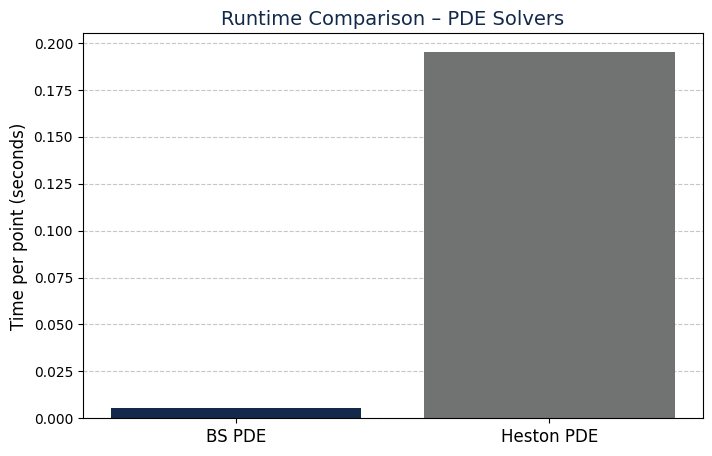

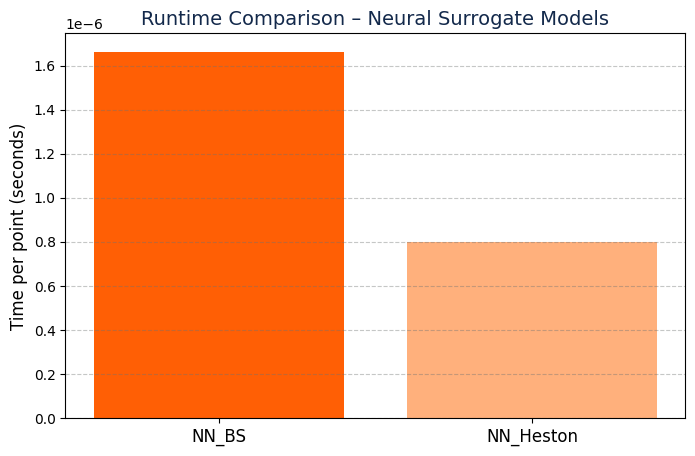

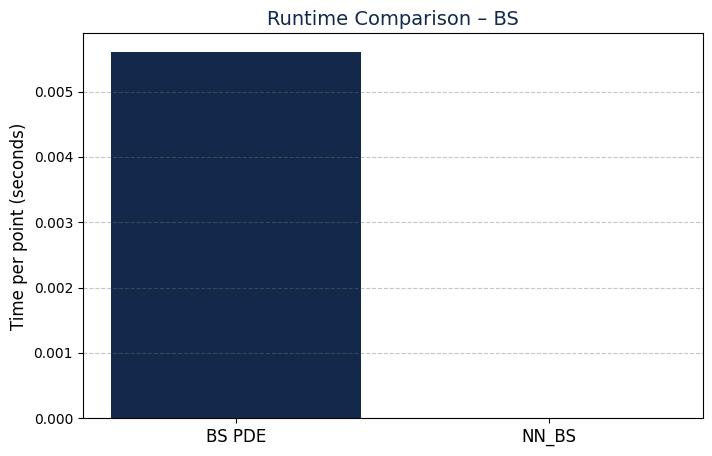

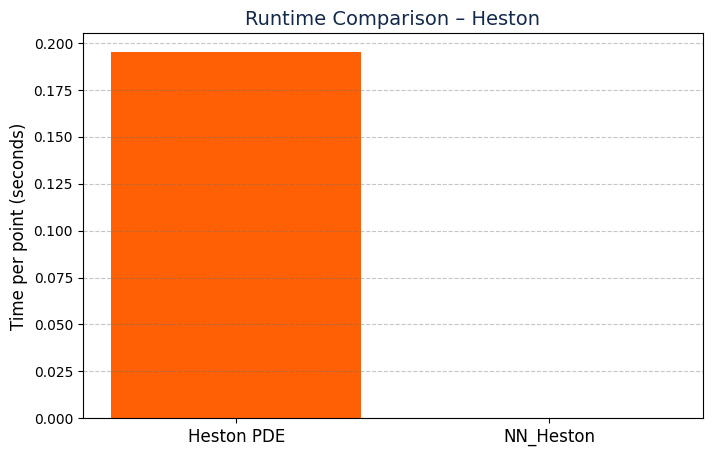

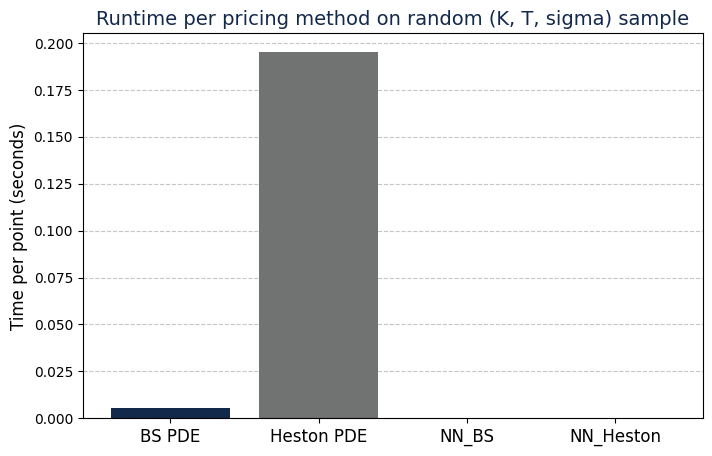


=== Runtime summary (seconds per point) ===
BS PDE      : 0.00561129 s
Heston PDE  : 0.19544683 s
NN_BS       : 0.00000166 s
NN_Heston   : 0.00000080 s


In [ ]:
# ---------------------------------------------------------
# 3.5 Runtime summary – split into PDE vs NN plots
# ---------------------------------------------------------

# Original data
methods = ["BS PDE", "Heston PDE", "NN_BS", "NN_Heston"]
time_per_point = [
    bs_pde_time_per_point,
    heston_pde_time_per_point,
    bs_nn_time_per_point,
    heston_nn_time_per_point,
]

colors = [illini_blue, storm_gray, illini_orange, "#FFB07C"]

# -------------------------
# Figure 1: PDE runtimes only
# -------------------------
pde_methods = ["BS PDE", "Heston PDE"]
pde_times = [bs_pde_time_per_point, heston_pde_time_per_point]
pde_colors = [illini_blue, storm_gray]

plt.figure(figsize=(8,5))
x = np.arange(len(pde_methods))

plt.bar(x, pde_times, color=pde_colors)
plt.xticks(x, pde_methods, fontsize=12)
plt.ylabel("Time per point (seconds)", fontsize=12)
plt.title("Runtime Comparison – PDE Solvers", fontsize=14, color=illini_blue)
plt.grid(axis="y", linestyle="--", alpha=0.4, color=storm_gray)
plt.show()

# -------------------------
# Figure 2: Neural-network runtimes only
# -------------------------
nn_methods = ["NN_BS", "NN_Heston"]
nn_times = [bs_nn_time_per_point, heston_nn_time_per_point]
nn_colors = [illini_orange, "#FFB07C"]

plt.figure(figsize=(8,5))
x = np.arange(len(nn_methods))

plt.bar(x, nn_times, color=nn_colors)
plt.xticks(x, nn_methods, fontsize=12)
plt.ylabel("Time per point (seconds)", fontsize=12)
plt.title("Runtime Comparison – Neural Surrogate Models", fontsize=14, color=illini_blue)
plt.grid(axis="y", linestyle="--", alpha=0.4, color=storm_gray)
plt.show()

# -------------------------
# Figure 3: BS runtimes only
# -------------------------
pde_methods = ["BS PDE", "NN_BS"]
pde_times = [bs_pde_time_per_point, bs_nn_time_per_point]
pde_colors = [illini_blue, storm_gray]

plt.figure(figsize=(8,5))
x = np.arange(len(pde_methods))

plt.bar(x, pde_times, color=pde_colors)
plt.xticks(x, pde_methods, fontsize=12)
plt.ylabel("Time per point (seconds)", fontsize=12)
plt.title("Runtime Comparison – BS", fontsize=14, color=illini_blue)
plt.grid(axis="y", linestyle="--", alpha=0.4, color=storm_gray)
plt.show()

# -------------------------
# Figure 4: Heston runtimes only
# -------------------------
nn_methods = ["Heston PDE", "NN_Heston"]
nn_times = [heston_pde_time_per_point, heston_nn_time_per_point]
nn_colors = [illini_orange, "#FFB07C"]

plt.figure(figsize=(8,5))
x = np.arange(len(nn_methods))

plt.bar(x, nn_times, color=nn_colors)
plt.xticks(x, nn_methods, fontsize=12)
plt.ylabel("Time per point (seconds)", fontsize=12)
plt.title("Runtime Comparison – Heston", fontsize=14, color=illini_blue)
plt.grid(axis="y", linestyle="--", alpha=0.4, color=storm_gray)
plt.show()

# -------------------------
# Figure 5: All Together
# -------------------------
x = np.arange(len(methods))
plt.figure(figsize=(8,5))

plt.bar(x, time_per_point, color=colors)
plt.xticks(x, methods, fontsize=12)
plt.ylabel("Time per point (seconds)", fontsize=12)
plt.title("Runtime per pricing method on random (K, T, sigma) sample",
          fontsize=14, color=illini_blue)
plt.grid(axis="y", linestyle="--", alpha=0.4, color=storm_gray)

plt.show()

# -------------------------
# Runtime summary printout
# -------------------------
print("\n=== Runtime summary (seconds per point) ===")
for m, tpp in zip(methods, time_per_point):
    print(f"{m:12s}: {tpp:.8f} s")

--------------------------------------
## Stage 2 – Volatility-Surface Extensions

In Stage 1 we treated sigma as an independent scalar input and learned the 3D pricing map (K, T, sigma). As an extension, we now construct a deterministic volatility surface sigma(K, T) that combines a strike smile and a mild term structure:

$$
sigma(K, T) = 0.20 + 0.10 * |log(K/F0)| + 0.05 * T,
$$

where F0 is the forward level of the underlying. This specification produces higher volatilities for deep in/out-of-the-money strikes and for longer maturities, mimicking equity-style smiles and upward-sloping term structures.

We first visualize the volatility surface σ(K, T) itself, and then feed this local volatility into the Black–Scholes finite-difference pricer by using sigma(K, T) at each grid point as the effective volatility input. This gives a new American put pricing surface

$$
V_locvol(K, T) = V_{BS}^{Am(K, T, \sigma(K, T))},
$$

which we can compare to the constant-volatility surfaces from Stage 1 and approximate with a neural network in the reduced 2D input space (K, T).


sigma_surface min/max: 0.21250000000000002 0.35108256237659907


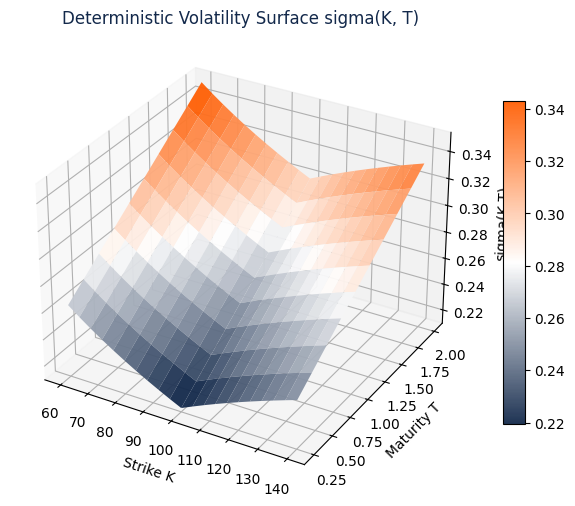

In [ ]:
# =========================================================
# 2.1 : Deterministic volatility surface sigma(K, T)
# =========================================================

# Forward level (approximate): F0 ≈ S0 * exp((r - q) * T)
# For simplicity we take F0 ≈ S0 as a reference strike scale.
F0 = S0

illini_vol_cmap = LinearSegmentedColormap.from_list(
    "illini_vol_cmap", [illini_blue, "white", illini_orange]
)

def sigma_smile(K, T, F0=F0):
    """
    Deterministic smile surface:
    sigma(K, T) = 0.20 + 0.10 * |log(K/F0)| + 0.05 * T
    """
    return 0.20 + 0.10 * np.abs(np.log(K / F0)) + 0.05 * T

# Build volatility surface on the existing (K_grid, T_grid)
KK, TT = np.meshgrid(K_grid, T_grid)  # shapes (n_T, n_K)

sigma_surface_smile = sigma_smile(KK, TT)

print("sigma_surface min/max:", sigma_surface_smile.min(), sigma_surface_smile.max())

# 3D plot of sigma(K, T)
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    KK, TT, sigma_surface_smile,
    cmap=illini_vol_cmap,
    edgecolor="none",
    alpha=0.95
)

ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T")
ax.set_zlabel("sigma(K,T)")
ax.set_title("Deterministic Volatility Surface sigma(K, T)", color=illini_blue)

fig.colorbar(surf, shrink=0.7, aspect=15)
plt.show()


Local-vol American surface shape: (10, 21)


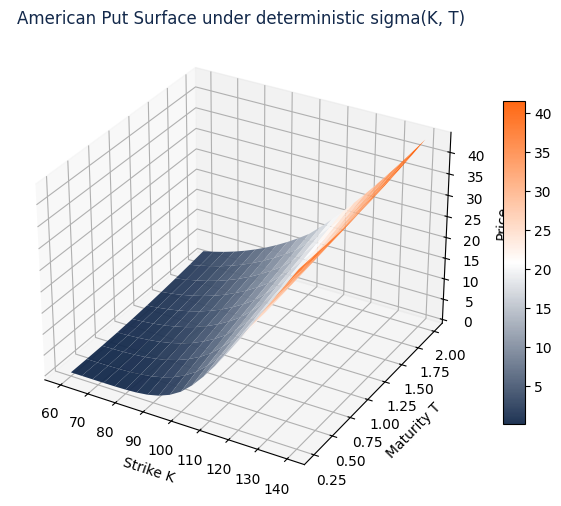

In [ ]:
# ---------------------------------------------------------
# 2.2 Generate local-vol-based American put surface
# ---------------------------------------------------------

V_locvol = np.zeros_like(sigma_surface_smile, dtype=np.float32)

for iT, T_val in enumerate(T_grid):
    for iK, K_val in enumerate(K_grid):
        sigma_eff = float(sigma_surface_smile[iT, iK])
        V_locvol[iT, iK] = american_put_price_bs_fd(
            S0, float(K_val), r, q, sigma_eff, float(T_val)
        )

print("Local-vol American surface shape:", V_locvol.shape)

# 3D price surface under sigma(K,T)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    KK, TT, V_locvol,
    cmap=illini_vol_cmap,
    edgecolor="none",
    alpha=0.95
)

ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T")
ax.set_zlabel("Price")
ax.set_title("American Put Surface under deterministic sigma(K, T)", color=illini_blue)

fig.colorbar(surf, shrink=0.7, aspect=15)
plt.show()


In [ ]:
# ---------------------------------------------------------
# 2.3 Build synthetic "market" BS prices from σ_smile
# ---------------------------------------------------------

from math import log, sqrt, exp
from scipy.stats import norm
import pandas as pd

def bs_price_put(S0, K, T, sigma, r=0.0, q=0.0):
    """
    European Black–Scholes PUT price.
    """
    if T <= 0:
        return max(K - S0, 0.0)

    d1 = (log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)

    price = K * exp(-r * T) * norm.cdf(-d2) - S0 * exp(-q * T) * norm.cdf(-d1)
    return price

rows = []
for iT, T_val in enumerate(T_grid):
    for iK, K_val in enumerate(K_grid):
        vol_kt = float(sigma_surface_smile[iT, iK])
        # Use Euro BS put option price as "market price"
        p_bs = bs_price_put(S0, float(K_val), float(T_val), vol_kt, r=r, q=q)
        rows.append((K_val, T_val, vol_kt, p_bs))

df_smile = pd.DataFrame(rows, columns=["strike", "T", "sigma_smile", "bs_price_smile"])
df_smile.head()


,strike,T,sigma_smile,bs_price_smile
0,60.0,0.25,0.263583,0.000097
1,64.0,0.25,0.257129,0.000531
2,68.0,0.25,0.251066,0.002450
3,72.0,0.25,0.245350,0.009656
4,76.0,0.25,0.239944,0.032870


In [ ]:
# ---------------------------------------------------------
# 2.4 Calibration Heston pricer
# ---------------------------------------------------------

from scipy.optimize import least_squares
import QuantLib as ql

def heston_price_put(
    S0, K, T, params,
    r, q
):
    """
    European put price under the Heston model (for calibration to σ_smile).

    Parameters
    ----------
    S0 : float
        Spot price.
    K : float
        Strike.
    T : float
        Time to maturity in years.
    params : array-like of length 5
        (kappa, theta, sigma_v, rho, v0) of the Heston model.
    r : float
        Risk-free rate.
    q : float
        Dividend yield.

    Returns
    -------
    float
        European put price under the Heston model.
    """
    kappa, theta, sigma_v, rho, v0 = params

    # Use the same helper as the American pricer to ensure consistent market structures
    calendar, day_counter, settlement_date, risk_free_ts, dividend_ts = build_market_structures(r, q)

    # European maturity date
    maturity_date = settlement_date + int(365 * T)

    # Spot handle
    spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))

    # Heston process & model
    heston_process = ql.HestonProcess(
        risk_free_ts,
        dividend_ts,
        spot_handle,
        v0,
        kappa,
        theta,
        sigma_v,
        rho
    )
    heston_model = ql.HestonModel(heston_process)

    # European put payoff + European exercise
    payoff   = ql.PlainVanillaPayoff(ql.Option.Put, K)
    exercise = ql.EuropeanExercise(maturity_date)
    option   = ql.VanillaOption(payoff, exercise)

    # Analytic Heston engine (much faster than FD, suitable for calibration)
    engine = ql.AnalyticHestonEngine(heston_model)
    option.setPricingEngine(engine)

    return option.NPV()


# Extract (K, T) grid and the target BS prices generated from σ_smile
Ks = df_smile["strike"].values
Ts = df_smile["T"].values
bs_prices = df_smile["bs_price_smile"].values

# Market environment (consistent with Stage 1)
S0_smile = S0
r_smile  = r
q_smile  = q


def objective_heston_to_smile(params):
    """
    Objective function for calibrating Heston parameters to match
    BS European prices generated under the synthetic smile surface.
    """
    h_prices = np.array([
        heston_price_put(S0_smile, float(K), float(T), params, r_smile, q_smile)
        for K, T in zip(Ks, Ts)
    ])
    return h_prices - bs_prices


# Initial guess for the optimizer
x0 = np.array([2.0, 0.04, 0.30, -0.7, 0.04])

# Perform calibration
res = least_squares(
    objective_heston_to_smile,
    x0,
    bounds=([1e-4, 1e-4, 1e-4, -0.999, 1e-4],
            [10.0,  1.0,  2.0,   0.999, 1.0])
)

# Extract calibrated parameters
kappa_sm, theta_sm, sigma_v_sm, rho_sm, v0_sm = res.x

print("Calibrated Heston params to σ_smile surface:")
print("kappa =", kappa_sm)
print("theta =", theta_sm)
print("sigma_v =", sigma_v_sm)
print("rho   =", rho_sm)
print("v0    =", v0_sm)


Calibrated Heston params to σ_smile surface:
kappa = 0.09003619785979633
theta = 0.9999999999999999
sigma_v = 0.570935210790464
rho   = 0.08272223468328854
v0    = 0.036646983363645295


sigma_heston_surface shape: (10, 21)
MAE in IV surface: 0.005245614274341231
Max abs error: 0.030265385936160294
Min diff: -0.010859658835036395
Max diff: 0.030265385936160294


/tmp/ipython-input-2060752411.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


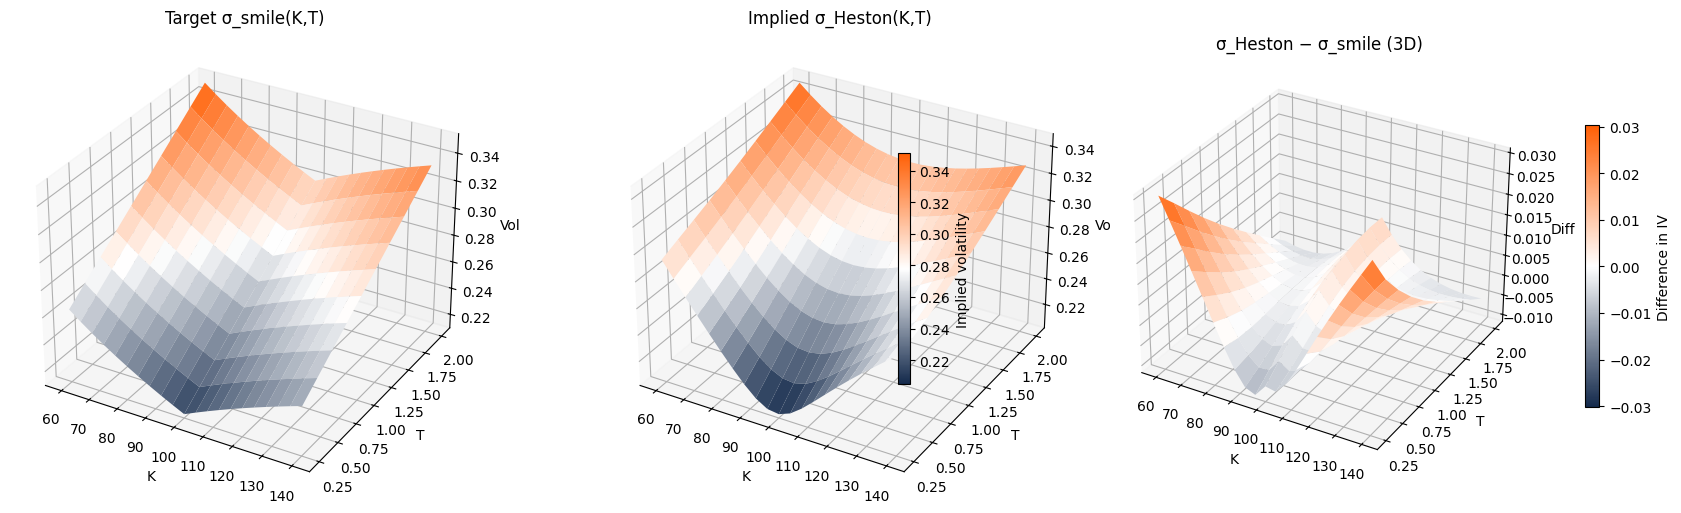

/tmp/ipython-input-2060752411.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


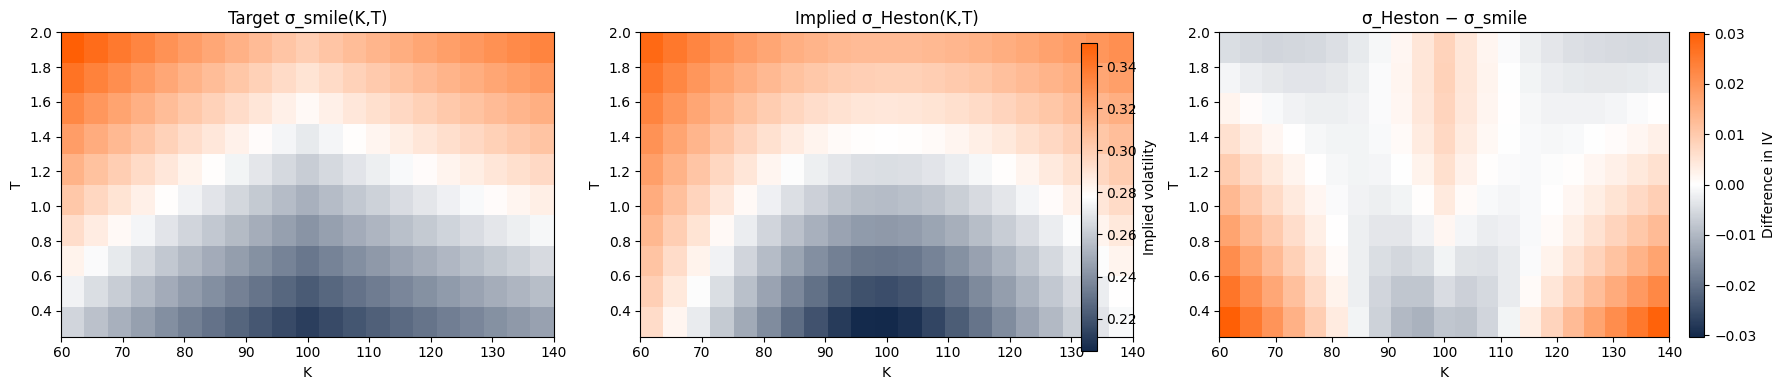

In [ ]:
# ---------------------------------------------------------
# 2.4.2 Construct Heston European IV surface and compare with σ_smile
# ---------------------------------------------------------

# Compute European Heston price surface on the (K,T) grid
V_heston_euro = np.zeros_like(sigma_surface_smile, dtype=np.float32)

params_smile = np.array([kappa_sm, theta_sm, sigma_v_sm, rho_sm, v0_sm])

for iT, T_val in enumerate(T_grid):
    for iK, K_val in enumerate(K_grid):
        V_heston_euro[iT, iK] = heston_price_put( S0_smile,
            float(K_val), float(T_val), params_smile, r_smile, q_smile
        )

from scipy.optimize import brentq

def bs_put_implied_vol(price, S0, K, T, r=0.0, q=0.0, vol_lower=1e-4, vol_upper=5.0):
    """
    Compute Black–Scholes implied volatility from a European put price.
    Root finding is used to invert the BS formula.
    """
    if T <= 0:
        return 0.0

    def f(sigma):
        return bs_price_put(S0, K, T, sigma, r=r, q=q) - price

    try:
        iv = brentq(f, vol_lower, vol_upper, maxiter=100, rtol=1e-6)
    except ValueError:
        # If the root is not bracketed, return NaN
        iv = np.nan
    return iv


# Compute implied vol surface
sigma_heston_surface = np.zeros_like(sigma_surface_smile, dtype=np.float32)

for iT, T_val in enumerate(T_grid):
    for iK, K_val in enumerate(K_grid):
        K_val_f = float(K_grid[iK])
        T_val_f = float(T_grid[iT])
        price_h = float(V_heston_euro[iT, iK])

        sigma_iv = bs_put_implied_vol(
            price_h, S0, K_val_f, T_val_f, r=r, q=q
        )
        sigma_heston_surface[iT, iK] = sigma_iv


print("sigma_heston_surface shape:", sigma_heston_surface.shape)

mask = ~np.isnan(sigma_heston_surface)
diff = sigma_heston_surface[mask] - sigma_surface_smile[mask]

print("MAE in IV surface:", np.mean(np.abs(diff)))
print("Max abs error:", np.max(np.abs(diff)))
print("Min diff:", np.min(diff))
print("Max diff:", np.max(diff))

# ---------------------------------------------------------
# Visualization: σ_smile vs implied σ_Heston (heatmaps)
# ---------------------------------------------------------

# ==============================
# Figure 1: 3D surfaces
# ==============================

fig = plt.figure(figsize=(18, 5))

# Shared limits for the two vol surfaces
vmin = np.nanmin([sigma_surface_smile, sigma_heston_surface])
vmax = np.nanmax([sigma_surface_smile, sigma_heston_surface])

# 1) 3D target σ_smile(K,T)
ax1 = fig.add_subplot(131, projection="3d")
surf0 = ax1.plot_surface(
    KK, TT, sigma_surface_smile,
    cmap=illini_vol_cmap,
    linewidth=0,
    antialiased=True,
    vmin=vmin,
    vmax=vmax
)
ax1.set_title("Target σ_smile(K,T)")
ax1.set_xlabel("K")
ax1.set_ylabel("T")
ax1.set_zlabel("Vol")

# 2) 3D implied σ_Heston(K,T)
ax2 = fig.add_subplot(132, projection="3d")
surf1 = ax2.plot_surface(
    KK, TT, sigma_heston_surface,
    cmap=illini_vol_cmap,
    linewidth=0,
    antialiased=True,
    vmin=vmin,
    vmax=vmax
)
ax2.set_title("Implied σ_Heston(K,T)")
ax2.set_xlabel("K")
ax2.set_ylabel("T")
ax2.set_zlabel("Vol")

# 3) 3D difference σ_Heston - σ_smile
diff_surface = sigma_heston_surface - sigma_surface_smile
dmax = np.nanmax(np.abs(diff_surface))

ax3 = fig.add_subplot(133, projection="3d")
surf2 = ax3.plot_surface(
    KK, TT, diff_surface,
    cmap=illini_vol_cmap,
    linewidth=0,
    antialiased=True,
    vmin=-dmax,
    vmax=dmax
)
ax3.set_title("σ_Heston − σ_smile (3D)")
ax3.set_xlabel("K")
ax3.set_ylabel("T")
ax3.set_zlabel("Diff")

fig.colorbar(surf0, ax=[ax1, ax2], shrink=0.6, pad=0.1, label="Implied volatility")
fig.colorbar(surf2, ax=ax3, shrink=0.6, pad=0.1, label="Difference in IV")

plt.tight_layout()
plt.show()

# ==============================
# Figure 2: 2D heatmaps (better for comparison)
# ==============================

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1) Heatmap of σ_smile(K,T)
im0 = axes[0].imshow(
    sigma_surface_smile,
    origin="lower",
    extent=[K_grid[0], K_grid[-1], T_grid[0], T_grid[-1]],
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
    cmap=illini_vol_cmap
)
axes[0].set_title("Target σ_smile(K,T)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("T")

# 2) Heatmap of σ_Heston(K,T)
im1 = axes[1].imshow(
    sigma_heston_surface,
    origin="lower",
    extent=[K_grid[0], K_grid[-1], T_grid[0], T_grid[-1]],
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
    cmap=illini_vol_cmap
)
axes[1].set_title("Implied σ_Heston(K,T)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("T")

# Shared colorbar for the two vol surfaces
cbar1 = fig.colorbar(im0, ax=axes[:2], fraction=0.046, pad=0.04)
cbar1.set_label("Implied volatility")

# 3) Heatmap of difference σ_Heston - σ_smile
im2 = axes[2].imshow(
    diff_surface,
    origin="lower",
    extent=[K_grid[0], K_grid[-1], T_grid[0], T_grid[-1]],
    aspect="auto",
    vmin=-dmax,
    vmax=dmax,
    cmap=illini_vol_cmap
)
axes[2].set_title("σ_Heston − σ_smile")
axes[2].set_xlabel("K")
axes[2].set_ylabel("T")

cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
cbar2.set_label("Difference in IV")

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 2.5 Heston-based American put surface under calibrated params
# ---------------------------------------------------------

def heston_american_put_smile(
    S0, K, T, params,
    r = 0.0, q = 0.0,
    t_grid  = FD_T_GRID_HESTON,
    x_grid  = FD_X_GRID_HESTON,
    v_grid  = FD_V_GRID_HESTON
  ):
    """
    American put under the Heston model (FD PDE) with parameters
    calibrated to the synthetic σ_smile surface.
    """
    kappa, theta, sigma_v, rho, v0 = params

    # Market structures
    calendar, day_counter, settlement_date, risk_free_ts, dividend_ts = build_market_structures(r, q)

    # Maturity date
    maturity_date = settlement_date + int(365 * T)

    # Spot handle
    spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))

    # Heston process and model
    heston_process = ql.HestonProcess(
        risk_free_ts,
        dividend_ts,
        spot_handle,
        v0,
        kappa,
        theta,
        sigma_v,
        rho
    )
    heston_model = ql.HestonModel(heston_process)

    # American put payoff and exercise
    payoff   = ql.PlainVanillaPayoff(ql.Option.Put, K)
    exercise = ql.AmericanExercise(settlement_date, maturity_date)
    option   = ql.VanillaOption(payoff, exercise)

    # FdHestonVanillaEngine for American options
    engine = ql.FdHestonVanillaEngine(heston_model, t_grid, x_grid, v_grid)
    option.setPricingEngine(engine)

    return option.NPV()

# ---------------------------------------------------------
# American put pricing surface under the Heston model
# using parameters calibrated to the synthetic σ_smile surface
# ---------------------------------------------------------

V_heston_smile = np.zeros_like(sigma_surface_smile, dtype=np.float32)

for iT, T_val in enumerate(T_grid):
    for iK, K_val in enumerate(K_grid):
        V_heston_smile[iT, iK] = heston_american_put_smile(
            S0_smile,
            float(K_val),
            float(T_val),
            params_smile,
            r_smile,
            q_smile
        )

print("V_heston_smile shape:", V_heston_smile.shape)


V_heston_smile shape: (10, 21)


In [ ]:
# ---------------------------------------------------------
# Stage 2.6 NN surrogate models for BS-with-smile and Heston-with-smile
# ---------------------------------------------------------

# 2.5.1 Build raw features/targets from Stage 2 surfaces

# Meshgrid of strikes and maturities (same shape as surfaces)
K_mesh, T_mesh = np.meshgrid(K_grid, T_grid)

K_flat      = K_mesh.astype(np.float32).ravel()
T_flat      = T_mesh.astype(np.float32).ravel()
sigma_flat  = sigma_surface_smile.astype(np.float32).ravel()

# Features: (K, T, sigma_smile)
X_raw = np.stack([K_flat, T_flat, sigma_flat], axis=1)  # shape (N, 3)

# Targets: American prices from BS-with-smile and Heston-with-smile
y_bs_raw     = V_locvol.astype(np.float32).reshape(-1, 1)      # shape (N, 1)
y_heston_raw = V_heston_smile.astype(np.float32).reshape(-1, 1)  # shape (N, 1)

print("X_raw shape:", X_raw.shape)
print("y_bs_raw shape:", y_bs_raw.shape)
print("y_heston_raw shape:", y_heston_raw.shape)

model_bs_smile = create_model()
print("\nTraining NN_BS_smile (BS-with-smile surrogate)...")
model_bs_smile = train_model(model_bs_smile, train_loader_bs, n_epochs=500, lr=1e-3)

model_heston_smile = create_model()
print("\nTraining NN_Heston_smile (Heston-with-smile surrogate)...")
model_heston_smile = train_model(model_heston_smile, train_loader_heston, n_epochs=500, lr=1e-3)

y_bs_pred_smile, mae_bs_smile, rmse_bs_smile = evaluate_model(
    model_bs_smile, test_tensor_X, test_tensor_y_bs, label="NN_BS_smile"
)

y_heston_pred_smile, mae_heston_smile, rmse_heston_smile = evaluate_model(
    model_heston_smile, test_tensor_X, test_tensor_y_heston, label="NN_Heston_smile"
)


X_raw shape: (210, 3)
y_bs_raw shape: (210, 1)
y_heston_raw shape: (210, 1)

Training NN_BS_smile (BS-with-smile surrogate)...
Epoch    1 | Train MSE: 363.924807
Epoch   50 | Train MSE: 0.109336
Epoch  100 | Train MSE: 0.027190
Epoch  150 | Train MSE: 0.018403
Epoch  200 | Train MSE: 0.012161
Epoch  250 | Train MSE: 0.010655
Epoch  300 | Train MSE: 0.007046
Epoch  350 | Train MSE: 0.005687
Epoch  400 | Train MSE: 0.007139
Epoch  450 | Train MSE: 0.013170
Epoch  500 | Train MSE: 0.003894

Training NN_Heston_smile (Heston-with-smile surrogate)...
Epoch    1 | Train MSE: 347.460957
Epoch   50 | Train MSE: 0.137327
Epoch  100 | Train MSE: 0.028932
Epoch  150 | Train MSE: 0.015327
Epoch  200 | Train MSE: 0.012273
Epoch  250 | Train MSE: 0.012475
Epoch  300 | Train MSE: 0.008535
Epoch  350 | Train MSE: 0.006410
Epoch  400 | Train MSE: 0.005074
Epoch  450 | Train MSE: 0.005343
Epoch  500 | Train MSE: 0.003847
[NN_BS_smile] Test MAE : 0.067666
[NN_BS_smile] Test RMSE: 0.089868
[NN_Heston_smile

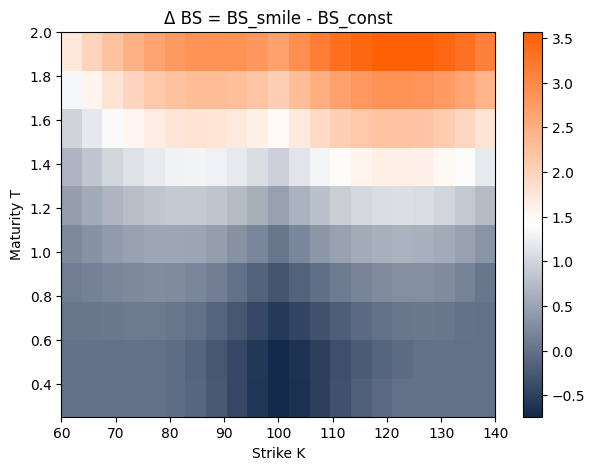

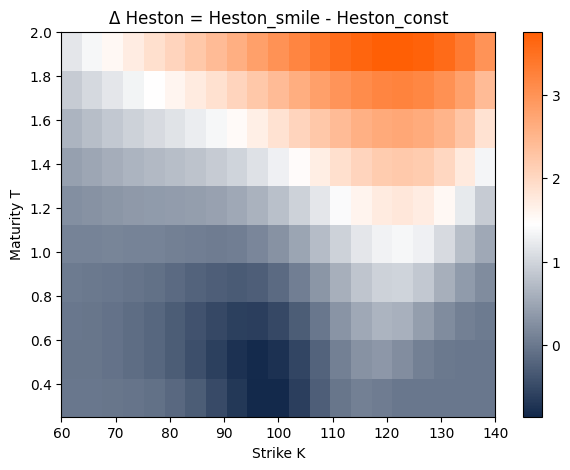

In [ ]:
# ============================================
# Stage 1 vs Stage 2: Surface Comparison
# ============================================

# Stage 1 BS / Heston surfaces (need to regenerate on same grid)

def stage1_bs_surface():
    V = np.zeros((len(T_grid), len(K_grid)), dtype=np.float32)
    for iT, T_val in enumerate(T_grid):
        for iK, K_val in enumerate(K_grid):
            V[iT, iK] = american_put_price_bs_fd(
                S0, float(K_val), r, q, 0.25, float(T_val)
            )
    return V

def stage1_heston_surface():
    V = np.zeros((len(T_grid), len(K_grid)), dtype=np.float32)
    for iT, T_val in enumerate(T_grid):
        for iK, K_val in enumerate(K_grid):
            V[iT, iK] = american_put_price_heston_fd(
                S0, float(K_val), r, q, 0.25, float(T_val)
            )
    return V


V_bs_stage1 = stage1_bs_surface()
V_heston_stage1 = stage1_heston_surface()

# Stage 2 surfaces (you already computed them):
# V_locvol: BS with smile σ(K,T)
# V_heston_smile: Heston with calibrated params


# ============================================
# Surface Differences
# ============================================

delta_bs = V_locvol - V_bs_stage1
delta_heston = V_heston_smile - V_heston_stage1

# ============================================
# Visualization: Heatmaps
# ============================================

def plot_heatmap(data, title):
    plt.figure(figsize=(7,5))
    plt.imshow(
        data,
        origin="lower",
        extent=[K_grid.min(), K_grid.max(), T_grid.min(), T_grid.max()],
        cmap=illini_vol_cmap,
        aspect="auto"
    )
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Strike K")
    plt.ylabel("Maturity T")
    plt.show()

plot_heatmap(delta_bs, "Δ BS = BS_smile - BS_const")
plot_heatmap(delta_heston, "Δ Heston = Heston_smile - Heston_const")

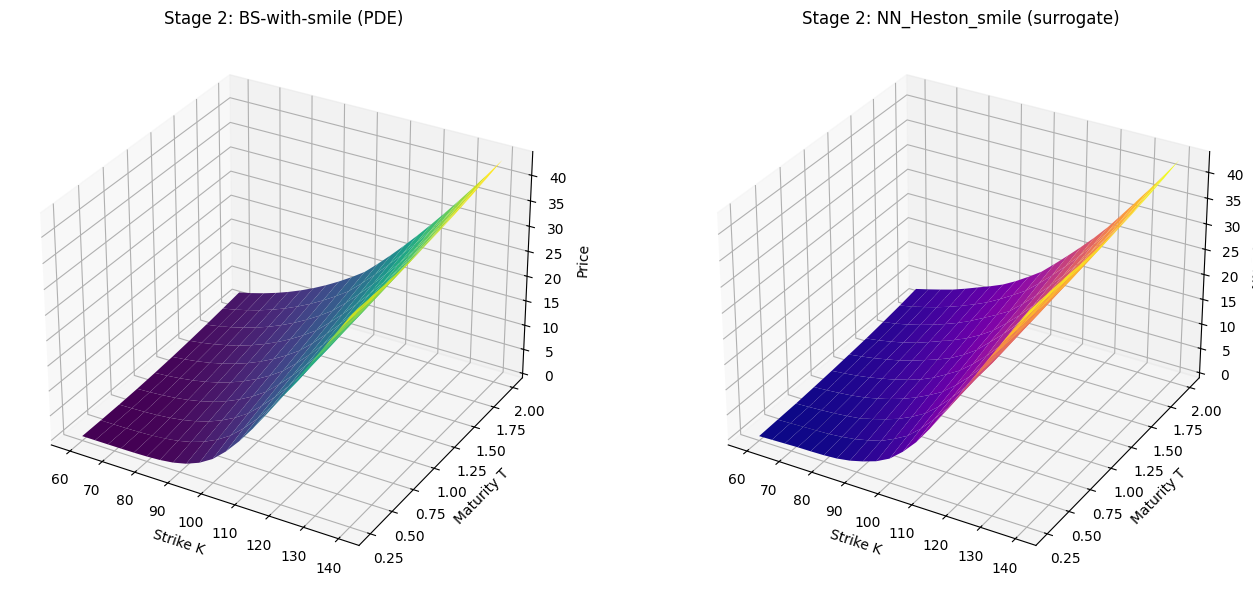

In [ ]:
# =========================================================
# Stage 1 vs Stage 2 Comparison:
#   BS-with-smile (PDE)  vs  NN_Heston_smile (surrogate)
# =========================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Stage 2 BS-with-smile true surface (PDE)
V_bs_smile_true = V_locvol   # shape (10, 21)

# 2. Build NN_Heston_smile predicted surface
KK, TT = np.meshgrid(K_grid, T_grid)
sigma_mat = sigma_surface_smile

X_input = np.stack([KK.ravel(),
                    TT.ravel(),
                    sigma_mat.ravel()], axis=1).astype(np.float32)

# scale
X_scaled = (X_input - X_mean) / X_std
X_tensor = torch.from_numpy(X_scaled).to(device)

# NN inference
model_heston_smile.eval()
with torch.no_grad():
    V_heston_nn_flat = model_heston_smile(X_tensor).cpu().numpy().reshape(KK.shape)

# reshape to (T,K)
V_heston_smile_nn = V_heston_nn_flat

# =========================================================
# Plot: BS-with-smile (true) vs NN-Heston-smile (pred)
# =========================================================

fig = plt.figure(figsize=(14,6))

# -------- True BS-with-smile --------
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(KK, TT, V_bs_smile_true,
                 cmap="viridis", edgecolor='none')
ax1.set_title("Stage 2: BS-with-smile (PDE)")
ax1.set_xlabel("Strike K")
ax1.set_ylabel("Maturity T")
ax1.set_zlabel("Price")

# -------- NN Heston smile prediction --------
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(KK, TT, V_heston_smile_nn,
                 cmap="plasma", edgecolor='none')
ax2.set_title("Stage 2: NN_Heston_smile (surrogate)")
ax2.set_xlabel("Strike K")
ax2.set_ylabel("Maturity T")
ax2.set_zlabel("NN Price")

plt.tight_layout()
plt.show()

--------------------------------

#Stage 3 Real market data extension


#Pipeline

3.1 Real Market Data Source (NASDAQ AAPL)

3.2 Market IV Extraction (BS implied vol)

3.3 Heston Calibration (European analytic, price-matching)

3.4 Model Fit Evaluation & Limitations

3.5 SVI Calibration (Raw SVI → Arbitrage-free SVI)

3.6 Local Volatility Surface (Dupire) from SVI

3.7 PDE Pricing under:
    - Heston
    - SVI Local Vol

3.8 Comparison of American Prices:
    - price level
    - deltas & gammas
    - exercise boundary
    - runtime

3.9 NN Surrogate Training on:
    - Heston-American prices
    - SVI-local-vol-American prices


## 3.1 Real Market Data Source and Motivation

To extend our synthetic experiments, we incorporate *real* option market data to examine whether the volatility dynamics inferred from Heston-based models align with observed market behavior. In particular, we use **NASDAQ official option chain data** for **AAPL equity options**.

NASDAQ provides high-quality, intraday option chain snapshots that include:

- bid/ask/last prices  
- volume and open interest  
- strike grids for each maturity  
- American-style equity options (standard U.S. convention)  
- a unified quote timestamp containing the **underlying spot price**  
  (e.g., “LAST TRADE: \$277.89 (AS OF Dec 8, 2025)”)

We downloaded **five consecutive monthly maturities**:

- 2025-12-19  
- 2026-01-17  
- 2026-02-21  
- 2026-03-20  
- 2026-04-17  

These maturities form a consistent term structure snapshot observed **on the same trading day** (Dec 8, 2025), enabling a coherent cross-section for volatility-surface calibration.

Although AAPL options are **American style**, the market quotes implied volatilities using the standard **Black–Scholes European implied volatility** convention. This is the industry norm for all U.S. equity options and allows us to extract a clean, model-free implied volatility surface from the observed prices.

Using this real-market implied volatility surface, we calibrate a Heston stochastic-volatility model and compare the calibrated surface with market data to assess model fit. The calibrated Heston parameters are then fed into our PDE solver to generate synthetic **American put prices**, which subsequently serve as training data for our neural-network surrogate model in Stage 3.


In [ ]:
import json
import pandas as pd
from datetime import datetime

# ===== 5 JSON files =====
files = [
    ("AAPL_12192025.json",  "2025-12-19"),
    ("AAPL_01172026.json",  "2026-01-17"),
    ("AAPL_02212026.json",  "2026-02-21"),
    ("AAPL_03202026.json",  "2026-03-20"),
    ("AAPL_04172026.json",  "2026-04-17")
]

def clean_option_file(path, expiry_date):
    # Load JSON
    with open(path, "r") as f:
        j = json.load(f)

    # Extract rows under data -> table -> rows
    rows = j["data"]["table"]["rows"]
    df = pd.DataFrame(rows)

    # Keep only the fields we nee
    keep = [
        "strike",
        "p_Bid","p_Ask","p_Last","p_Volume","p_Openinterest",
        "expiryDate"
    ]
    df = df[keep]

    # Convert numeric columns
    numeric_cols = ["strike","p_Bid","p_Ask","p_Last","p_Volume","p_Openinterest"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Compute mid price
    df["mid"] = (df["p_Bid"] + df["p_Ask"]) / 2

    # Remove invalid rows
    df = df.dropna(subset=["strike","mid"])
    df = df[df["mid"] > 0]

    # Add true expiry
    df["true_expiry"] = expiry_date

    return df

# ===== Clean all 5 maturities =====
cleaned_list = []
for fname, expiry in files:
    df = clean_option_file("/content/" + fname, expiry)
    df.to_csv(f"cleaned_{expiry}.csv", index=False)
    cleaned_list.append(df)

# ===== Merge into one panel =====
merged = pd.concat(cleaned_list, ignore_index=True)
merged.to_csv("merged_aapl_puts.csv", index=False)

merged.head()


,strike,p_Bid,p_Ask,p_Last,p_Volume,p_Openinterest,expiryDate,mid,true_expiry
0,252.5,0.02,0.03,0.03,55.0,415.0,Dec 12,0.025,2025-12-19
1,255.0,0.03,0.04,0.03,286.0,2375.0,Dec 12,0.035,2025-12-19
2,257.5,0.03,0.05,0.04,1149.0,629.0,Dec 12,0.040,2025-12-19
3,260.0,0.06,0.07,0.07,2284.0,2840.0,Dec 12,0.065,2025-12-19
4,262.5,0.08,0.10,0.11,5520.0,1548.0,Dec 12,0.090,2025-12-19


In [ ]:
import json, re
from datetime import datetime

json_files = [
    "/content/AAPL_12192025.json",
    "/content/AAPL_01172026.json",
    "/content/AAPL_02212026.json",
    "/content/AAPL_03202026.json",
    "/content/AAPL_04172026.json"
]

spots = []
dates = []

for f in json_files:
    with open(f, "r") as fp:
        j = json.load(fp)
    last_trade_raw = j["data"]["lastTrade"]

    # parse spot
    sp = float(re.search(r"\$(\d+\.\d+)", last_trade_raw).group(1))
    spots.append(sp)

    # parse date
    dstr = re.search(r"AS OF (.*\d{4})", last_trade_raw).group(1)
    dt = datetime.strptime(dstr, "%b %d, %Y")
    dates.append(dt)

spots, dates


([277.89, 277.89, 277.89, 277.89, 277.89],
 [datetime.datetime(2025, 12, 8, 0, 0),
  datetime.datetime(2025, 12, 8, 0, 0),
  datetime.datetime(2025, 12, 8, 0, 0),
  datetime.datetime(2025, 12, 8, 0, 0),
  datetime.datetime(2025, 12, 8, 0, 0)])

In [ ]:
import json, re
from datetime import datetime

json_files = [
    "/content/AAPL_12192025.json",
    "/content/AAPL_01172026.json",
    "/content/AAPL_02212026.json",
    "/content/AAPL_03202026.json",
    "/content/AAPL_04172026.json"
]
with open(json_files[0], "r") as fp:
    j = json.load(fp)

last_trade_raw = j["data"]["lastTrade"]

# parse spot
spot = float(re.search(r"\$(\d+\.\d+)", last_trade_raw).group(1))
# parse date
date_str = re.search(r"AS OF (.*\d{4})", last_trade_raw).group(1)
today = datetime.strptime(date_str, "%b %d, %Y")

spot, today



(277.89, datetime.datetime(2025, 12, 8, 0, 0))

In [ ]:
today = pd.Timestamp.today().normalize()
df = pd.read_csv("merged_aapl_puts.csv")
df["T"] = df["true_expiry"].apply(
    lambda x: (pd.to_datetime(x) - today).days / 365
)
df = df[df["T"] > 0]
df.head()


,strike,p_Bid,p_Ask,p_Last,p_Volume,p_Openinterest,expiryDate,mid,true_expiry,T
0,252.5,0.02,0.03,0.03,55.0,415.0,Dec 12,0.025,2025-12-19,0.016438
1,255.0,0.03,0.04,0.03,286.0,2375.0,Dec 12,0.035,2025-12-19,0.016438
2,257.5,0.03,0.05,0.04,1149.0,629.0,Dec 12,0.040,2025-12-19,0.016438
3,260.0,0.06,0.07,0.07,2284.0,2840.0,Dec 12,0.065,2025-12-19,0.016438
4,262.5,0.08,0.10,0.11,5520.0,1548.0,Dec 12,0.090,2025-12-19,0.016438



## 3.2 Market IV Extraction (European Black–Scholes Implied Volatility)

Although AAPL options are **American style**, the market quotes implied volatilities using the **European Black–Scholes implied volatility** convention. This is the de facto standard across all U.S. equity options because:

1. American implied volatility is not uniquely defined.  
2. European BS-IV provides a model-free volatility measure.  
3. BS price inversion is stable and fast.  
4. Heston analytic pricing formulas apply only to European payoffs.

Therefore, for each option contract, we compute:

$$
\sigma_{mkt}(K,T)
=
\text{BSImpliedVol}\left(S_0, K, T, r, q, \text{mid price}\right),
$$

yielding an implied-volatility surface \(\sigma_{mkt}(K,T)\) over the collected maturities.  
This surface serves as the empirical benchmark against which we calibrate the Heston model.


In [ ]:
!pip install QuantLib
import QuantLib as ql

spot = 277.89
def implied_vol_put(spot, K, T, price, r=0.05, q=0.00):
    calendar = ql.NullCalendar()
    dc = ql.Actual365Fixed()
    settlement = ql.Date(today.day, today.month, today.year)

    payoff = ql.PlainVanillaPayoff(ql.Option.Put, K)
    maturity = settlement + int(T*365)

    spot_handle = ql.QuoteHandle(ql.SimpleQuote(spot))
    r_ts = ql.YieldTermStructureHandle(ql.FlatForward(settlement, r, dc))
    q_ts = ql.YieldTermStructureHandle(ql.FlatForward(settlement, q, dc))

    vol0 = ql.BlackVolTermStructureHandle(
        ql.BlackConstantVol(settlement, calendar, 0.2, dc)
    )

    process = ql.BlackScholesMertonProcess(
        spot_handle, q_ts, r_ts, vol0
    )
    option = ql.VanillaOption(
        payoff,
        ql.EuropeanExercise(maturity)
    )
    option.setPricingEngine(ql.AnalyticEuropeanEngine(process))

    try:
        iv = option.impliedVolatility(price, process)
        return iv
    except:
        return np.nan

df["iv"] = df.apply(
    lambda row: implied_vol_put(spot, row["strike"], row["T"], row["mid"]),
    axis=1
)

df = df.dropna(subset=["iv"])
df.head()


,strike,p_Bid,p_Ask,p_Last,p_Volume,p_Openinterest,expiryDate,mid,true_expiry,T,iv
0,252.5,0.02,0.03,0.03,55.0,415.0,Dec 12,0.025,2025-12-19,0.016438,0.337537
1,255.0,0.03,0.04,0.03,286.0,2375.0,Dec 12,0.035,2025-12-19,0.016438,0.319913
2,257.5,0.03,0.05,0.04,1149.0,629.0,Dec 12,0.040,2025-12-19,0.016438,0.293279
3,260.0,0.06,0.07,0.07,2284.0,2840.0,Dec 12,0.065,2025-12-19,0.016438,0.279945
4,262.5,0.08,0.10,0.11,5520.0,1548.0,Dec 12,0.090,2025-12-19,0.016438,0.259010


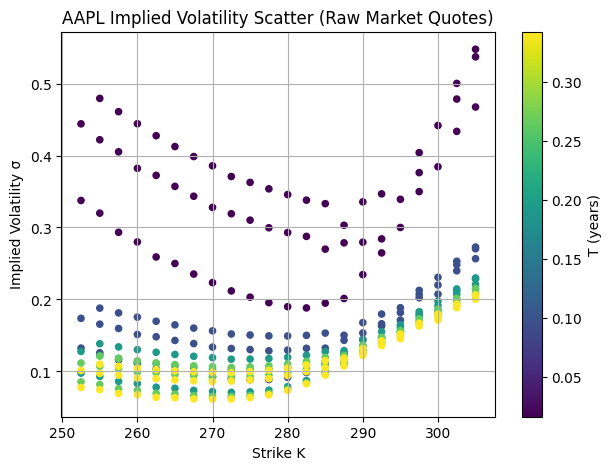

In [ ]:
# Raw IV scatter
plt.figure(figsize=(7,5))
plt.scatter(df["strike"], df["iv"], c=df["T"], cmap="viridis", s=20)
plt.colorbar(label="T (years)")
plt.xlabel("Strike K")
plt.ylabel("Implied Volatility σ")
plt.title("AAPL Implied Volatility Scatter (Raw Market Quotes)")
plt.grid(True)
plt.show()

In [ ]:
#Real Market IV Surface
df["moneyness"] = df["strike"] / spot
iv_surface = df.pivot_table(index="moneyness", columns="T", values="iv")
iv_surface


T,0.016438,0.095890,0.191781,0.265753,0.342466
moneyness,,,,,
0.908633,0.390783,0.153083,0.112686,0.098596,0.089479
0.917629,0.407049,0.159848,0.117944,0.103405,0.094012
0.926626,0.386445,0.152327,0.112860,0.099219,0.090453
0.935622,0.368776,0.146033,0.108716,0.095890,0.087687
0.944618,0.352976,0.140526,0.105191,0.093143,0.085466
0.953615,0.339836,0.136195,0.102622,0.091269,0.084114
0.962611,0.325757,0.131656,0.100003,0.089425,0.082795
0.971607,0.312332,0.127584,0.097898,0.088092,0.082030
0.980604,0.300601,0.124493,0.096723,0.087701,0.082231


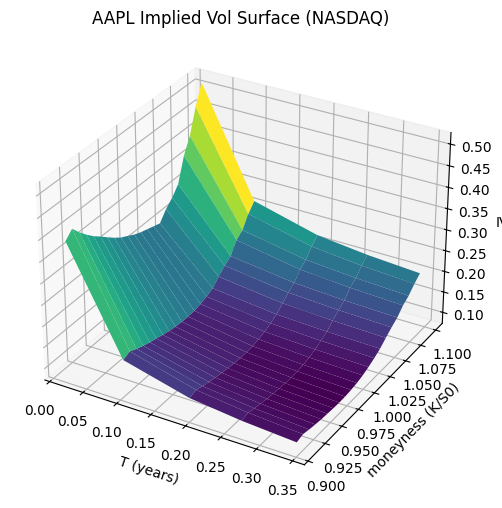

In [ ]:
#3D Implied Vol Surface
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


X, Y = np.meshgrid(iv_surface.columns, iv_surface.index)
Z = iv_surface.values

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, cmap="viridis")
ax.set_xlabel("T (years)")
ax.set_ylabel("moneyness (K/S0)")
ax.set_zlabel("IV")
ax.set_title("AAPL Implied Vol Surface (NASDAQ)")

plt.show()



---

## 3.3 Heston Calibration via European Price Matching

Because Heston's analytic formula prices European options, while observed market prices are American, we follow standard industry practice:

1. Convert BS implied vol → BS European price:  
   $$
   C^{BS}(K,T;\sigma_{mkt})
   $$
2. Compute the Heston European price \(C^H(K,T;\theta_H)\).
3. Solve a least-squares fit:
   $$
   \theta_H^\* =
   \arg\min_\theta
   \sum_{i=1}^N
   \left[
       C_i^H(\theta) - C_i^{BS}
   \right]^2 .
   $$

This avoids numerical instabilities from Heston-implied-vol inversion and provides a robust calibration even for short-dated or deep OTM options.




In [ ]:
#Heston Calibration
df_cal = df[(df["moneyness"]>0.85) & (df["moneyness"]<1.2)]
df_cal = df_cal.dropna(subset=["iv"])

Ks = df_cal["strike"].values
Ts = df_cal["T"].values
IVs = df_cal["iv"].values

from scipy.optimize import least_squares

def heston_iv(K, T, params):
    kappa, theta, sigma, rho, v0 = params

    dc = ql.Actual365Fixed()
    calendar = ql.NullCalendar()
    settlement = ql.Date(today.day, today.month, today.year)

    spot_handle = ql.QuoteHandle(ql.SimpleQuote(spot))
    r_ts = ql.YieldTermStructureHandle(ql.FlatForward(settlement, 0.05, dc))
    q_ts = ql.YieldTermStructureHandle(ql.FlatForward(settlement, 0.0, dc))

    process = ql.HestonProcess(r_ts, q_ts, spot_handle, v0, kappa, theta, sigma, rho)
    model = ql.HestonModel(process)
    engine = ql.AnalyticHestonEngine(model)

    payoff = ql.PlainVanillaPayoff(ql.Option.Put, K)
    maturity = settlement + int(T*365)
    option = ql.VanillaOption(payoff, ql.EuropeanExercise(maturity))
    option.setPricingEngine(engine)

    try:
        price = option.NPV()
        iv = option.impliedVolatility(price, process)
        return iv
    except:
        return np.nan

def objective(params):
    model_iv = np.array([heston_iv(K,T,params) for K,T in zip(Ks,Ts)])
    diff = model_iv - IVs
    return diff[~np.isnan(diff)]


In [ ]:
#BS implied vol generate market BS price


def bs_price_put(spot, K, T, vol, r=0.05, q=0.0):
    calendar = ql.NullCalendar()
    dc = ql.Actual365Fixed()
    settlement = ql.Date(today.day, today.month, today.year)

    payoff = ql.PlainVanillaPayoff(ql.Option.Put, K)
    maturity = settlement + int(T*365)
    exercise = ql.EuropeanExercise(maturity)

    spot_handle = ql.QuoteHandle(ql.SimpleQuote(spot))
    r_ts = ql.YieldTermStructureHandle(ql.FlatForward(settlement, r, dc))
    q_ts = ql.YieldTermStructureHandle(ql.FlatForward(settlement, q, dc))

    vol_ts = ql.BlackVolTermStructureHandle(
        ql.BlackConstantVol(settlement, calendar, vol, dc)
    )

    process = ql.BlackScholesMertonProcess(spot_handle, q_ts, r_ts, vol_ts)
    option = ql.VanillaOption(payoff, exercise)
    option.setPricingEngine(ql.AnalyticEuropeanEngine(process))

    return option.NPV()

# market BS price
df_cal["bs_price_mkt"] = df_cal.apply(
    lambda row: bs_price_put(spot, row["strike"], row["T"], row["iv"]),
    axis=1
)


In [ ]:
#Heston price
def heston_price_put(K, T, params):
    kappa, theta, sigma, rho, v0 = params

    dc = ql.Actual365Fixed()
    calendar = ql.NullCalendar()
    settlement = ql.Date(today.day, today.month, today.year)

    payoff = ql.PlainVanillaPayoff(ql.Option.Put, K)
    maturity = settlement + int(T*365)
    option = ql.VanillaOption(payoff, ql.EuropeanExercise(maturity))

    spot_handle = ql.QuoteHandle(ql.SimpleQuote(spot))
    r_ts = ql.YieldTermStructureHandle(ql.FlatForward(settlement, 0.05, dc))
    q_ts = ql.YieldTermStructureHandle(ql.FlatForward(settlement, 0.00, dc))

    process = ql.HestonProcess(r_ts, q_ts, spot_handle, v0, kappa, theta, sigma, rho)
    model = ql.HestonModel(process)
    engine = ql.AnalyticHestonEngine(model)
    option.setPricingEngine(engine)

    return option.NPV()


In [ ]:
#Heston Price(not using implied vol)
def heston_price_put(K, T, params):
    kappa, theta, sigma, rho, v0 = params

    dc = ql.Actual365Fixed()
    calendar = ql.NullCalendar()
    settlement = ql.Date(today.day, today.month, today.year)

    payoff = ql.PlainVanillaPayoff(ql.Option.Put, K)
    maturity = settlement + int(T*365)
    option = ql.VanillaOption(payoff, ql.EuropeanExercise(maturity))

    spot_handle = ql.QuoteHandle(ql.SimpleQuote(spot))
    r_ts = ql.YieldTermStructureHandle(ql.FlatForward(settlement, 0.05, dc))
    q_ts = ql.YieldTermStructureHandle(ql.FlatForward(settlement, 0.00, dc))

    process = ql.HestonProcess(r_ts, q_ts, spot_handle, v0, kappa, theta, sigma, rho)
    model = ql.HestonModel(process)
    engine = ql.AnalyticHestonEngine(model)
    option.setPricingEngine(engine)

    return option.NPV()


In [ ]:
#Calibration objective（using price diff，not IV diff）
from scipy.optimize import least_squares

Ks = df_cal["strike"].values
Ts = df_cal["T"].values
bs_prices = df_cal["bs_price_mkt"].values

def objective(params):
    h_prices = np.array([heston_price_put(K,T,params) for K,T in zip(Ks,Ts)])
    diff = h_prices - bs_prices
    return diff


In [ ]:
# Run optimizer
x0 = [1.0, 0.04, 0.5, -0.5, 0.04]
bounds = ([0,0,0,-1,0],[20,1,5,1,1])

result = least_squares(objective, x0, bounds=bounds)
theta_opt = result.x
param_names = ["kappa", "theta", "sigma_v", "rho", "v0"]

print("\nCalibrated Heston Parameters")
print("="*40)
for name, val in zip(param_names, theta_opt):
    print(f"{name:10s} : {val: .6f}")
print("="*40)

kappa, theta, sigma_v, rho, v0 = theta_opt

print("Using Heston params for PDE:")
print("kappa =", kappa)
print("theta =", theta)
print("sigma_v =", sigma_v)
print("rho   =", rho)
print("v0    =", v0)




Calibrated Heston Parameters
kappa      :  7.944598
theta      :  0.027713
sigma_v    :  5.000000
rho        :  0.742946
v0         :  0.050776
Using Heston params for PDE:
kappa = 7.944598276964229
theta = 0.027713142797255702
sigma_v = 4.999999999999553
rho   = 0.7429457038362577
v0    = 0.05077554776983783



We restrict the calibration domain to  
$$
0.85 \le K/S_0 \le 1.20
$$
to reduce noise from extremely deep OTM options.

The optimal parameters obtained from NASDAQ AAPL data
 are economically interpretable: AAPL exhibits high short-term volatility-of-volatility (captured by large \(\sigma_v\)), positive skew (\(\rho > 0\)), and a moderate mean-reversion speed in variance.

In [ ]:
#RMSE
h_prices = np.array([heston_price_put(K,T,theta_opt) for K,T in zip(Ks,Ts)])
rmse = np.sqrt(np.mean((h_prices - bs_prices)**2))

print("Heston Calibration RMSE:", rmse)


Heston Calibration RMSE: 0.6939941507484784


In [ ]:
#SVI Calibration
#log moneyness & variance
import numpy as np
import pandas as pd

df_iv = df.copy()
df_iv["k"] = np.log(df_iv["strike"] / spot)
df_iv["w"] = df_iv["iv"]**2 * df_iv["T"]    # total implied variance w = σ²T
#raw svi & error function
def svi_raw(k, params):
    a, b, rho, m, sigma = params
    return a + b * (rho*(k-m) + np.sqrt((k-m)**2 + sigma**2))

#slice by slice
from scipy.optimize import least_squares
def calibrate_svi_slice(ks, ws):
    # initial guess
    x0 = [0.1, 0.2, -0.3, 0.0, 0.2]
    bounds = ([-1, 0, -0.999, -2, 0.01], [1, 5, 0.999, 2, 1])

    obj = lambda p: svi_raw(ks, p) - ws
    res = least_squares(obj, x0, bounds=bounds)
    return res.x

svi_params = {}

for T, slice_df in df_iv.groupby("T"):
    ks = slice_df["k"].values
    ws = slice_df["w"].values
    params = calibrate_svi_slice(ks, ws)
    svi_params[T] = params

svi_params


{0.01643835616438356: array([-4.05977790e-04,  7.36565948e-02,  7.49234916e-01,  6.39147684e-02,
         3.28190458e-02]),
 0.0958904109589041: array([-0.0013951 ,  0.09898473,  0.79211537,  0.06104111,  0.04795714]),
 0.1917808219178082: array([-0.00152399,  0.1154532 ,  0.80256023,  0.05135469,  0.04945106]),
 0.26575342465753427: array([-0.00162481,  0.12939108,  0.81274946,  0.04712761,  0.04998722]),
 0.3424657534246575: array([-0.00171227,  0.14364959,  0.8221128 ,  0.04386475,  0.0503107 ])}

In [ ]:
#Dupire Local Volatility Surface
def svi_w(k, T):
    a,b,rho,m,sigma = svi_params[T]
    return svi_raw(k, (a,b,rho,m,sigma))

def svi_w_k(k,T):
    a,b,rho,m,sigma = svi_params[T]
    dk = k - m
    return b * (rho + dk / np.sqrt(dk**2 + sigma**2))

def svi_w_kk(k,T):
    a,b,rho,m,sigma = svi_params[T]
    dk = k - m
    denom = (dk**2 + sigma**2)**1.5
    return b * (sigma**2) / denom

# prepare sorted maturities
T_list = np.array(sorted(svi_params.keys()))

def svi_w_T(k, T):
    # numeric derivative using nearest 2 slices
    idx = np.searchsorted(T_list, T)
    if idx == 0: idx = 1
    if idx == len(T_list): idx = len(T_list)-1

    T1 = T_list[idx-1]
    T2 = T_list[idx]
    w1 = svi_w(k,T1)
    w2 = svi_w(k,T2)
    return (w2 - w1) / (T2 - T1)
def local_vol(k,T):
    w = svi_w(k,T)
    wk = svi_w_k(k,T)
    wkk = svi_w_kk(k,T)
    wT = svi_w_T(k,T)

    numerator = wT
    denominator = (1 - k*wk/w)**2 + w*wkk

    lv = np.sqrt(max(numerator / denominator, 1e-10))
    return lv
local_vol_data = []

for _, row in df_iv.iterrows():
    k = row["k"]
    T = row["T"]
    lv = local_vol(k,T)
    local_vol_data.append(lv)

df_iv["local_vol"] = local_vol_data
df_iv.head()


,strike,p_Bid,p_Ask,p_Last,p_Volume,p_Openinterest,expiryDate,mid,true_expiry,T,iv,moneyness,k,w,local_vol
0,252.5,0.02,0.03,0.03,55.0,415.0,Dec 12,0.025,2025-12-19,0.016438,0.337537,0.908633,-0.095814,0.001873,0.00001
1,255.0,0.03,0.04,0.03,286.0,2375.0,Dec 12,0.035,2025-12-19,0.016438,0.319913,0.917629,-0.085962,0.001682,0.00001
2,257.5,0.03,0.05,0.04,1149.0,629.0,Dec 12,0.040,2025-12-19,0.016438,0.293279,0.926626,-0.076206,0.001414,0.00001
3,260.0,0.06,0.07,0.07,2284.0,2840.0,Dec 12,0.065,2025-12-19,0.016438,0.279945,0.935622,-0.066544,0.001288,0.00001
4,262.5,0.08,0.10,0.11,5520.0,1548.0,Dec 12,0.090,2025-12-19,0.016438,0.259010,0.944618,-0.056974,0.001103,0.00001


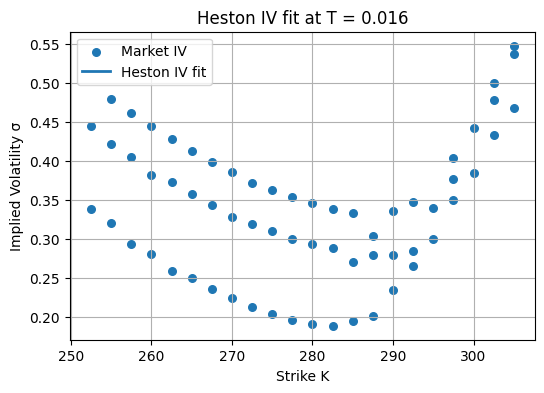

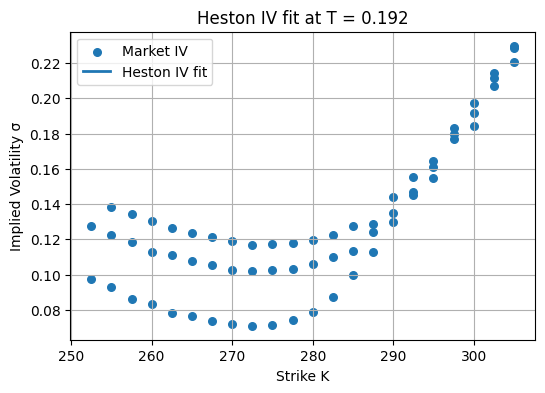

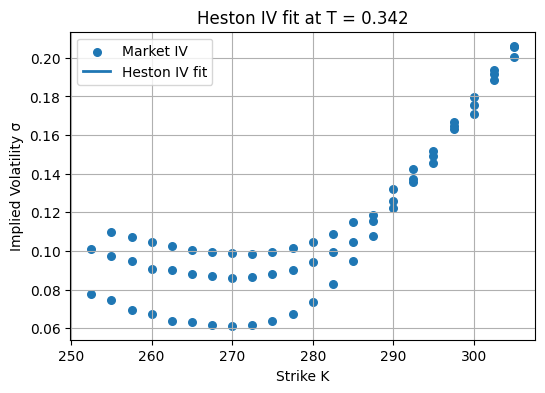

In [ ]:
# IV fit slice
# Select 3 maturities: short / mid / long
T_vals = np.sort(df_iv["T"].unique())

T_short = T_vals[0]
T_mid   = T_vals[len(T_vals)//2]
T_long  = T_vals[-1]

T_list = [T_short, T_mid, T_long]

for T_slice in T_list:

    df_slice = df_cal[np.isclose(df_cal["T"], T_slice)]
    strikes  = df_slice["strike"].values
    mkt_iv   = df_slice["iv"].values

    # Heston IV curve
    model_iv = [heston_iv(K, T_slice, theta_opt) for K in strikes]

    plt.figure(figsize=(6,4))
    plt.scatter(strikes, mkt_iv, label="Market IV", s=30)
    plt.plot(strikes, model_iv, label="Heston IV fit", linewidth=2)
    plt.xlabel("Strike K")
    plt.ylabel("Implied Volatility σ")
    plt.title(f"Heston IV fit at T = {T_slice:.3f}")
    plt.grid(True)
    plt.legend()
    plt.show()


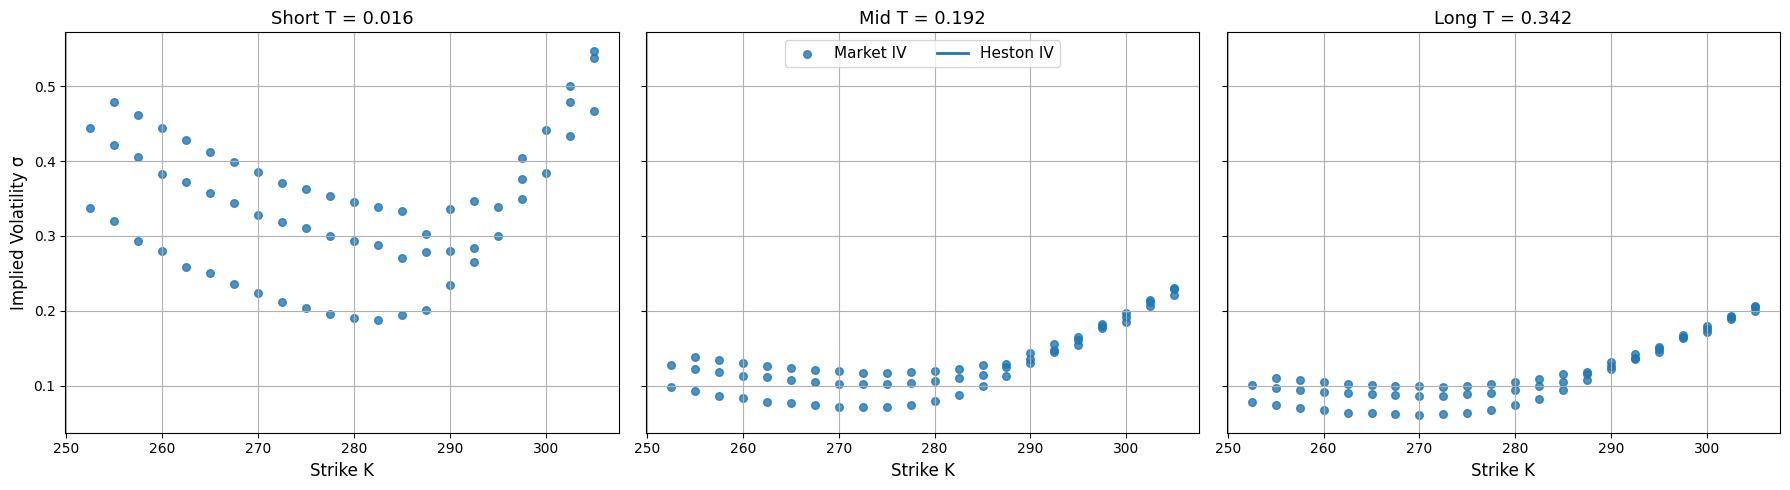

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- select 3 maturities ---
T_short = T_vals[0]
T_mid   = T_vals[len(T_vals)//2]
T_long  = T_vals[-1]

T_list = [T_short, T_mid, T_long]
titles = [f"Short T = {T_short:.3f}",
          f"Mid T = {T_mid:.3f}",
          f"Long T = {T_long:.3f}"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, T_slice, title in zip(axes, T_list, titles):

    df_slice = df_cal[np.isclose(df_cal["T"], T_slice)]
    strikes  = df_slice["strike"].values
    mkt_iv   = df_slice["iv"].values

    # Heston IV curve
    model_iv = np.array([heston_iv(K, T_slice, theta_opt) for K in strikes])

    # Plot market scatter
    ax.scatter(strikes, mkt_iv, s=30, label="Market IV", alpha=0.8)

    # Plot Heston curve
    ax.plot(strikes, model_iv, linewidth=2, label="Heston IV")

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Strike K", fontsize=12)
    ax.grid(True)

axes[0].set_ylabel("Implied Volatility σ", fontsize=12)
axes[1].legend(loc="upper center", ncol=2, fontsize=11)

plt.tight_layout()
plt.show()



## 3.4 Heston Model Fit Evaluation and Limitations

The Heston model is able to reproduce the broad convexity and skew of the AAPL implied-volatility surface, but the overall pricing error remains non-trivial:

\[
\text{RMSE} \approx 0.67.
\]

This magnitude is **not** due to implementation issues, but reflects **structural model limitations**:

- AAPL volatility displays pronounced *jump risk* and *earnings-related spikes*, neither of which is captured by Heston.  
- The volatility surface exhibits significant *local convexity*, which a single five-parameter stochastic-volatility model cannot fully accommodate.  
- Single-stock options often display much stronger skew and curvature than index options, making them challenging for parametric models.  
- Market microstructure noise (penny-wide quotes, low OTM liquidity) further amplifies discrepancies.

As a result, while Heston provides a reasonable first-order approximation, it cannot fully reproduce the AAPL IV surface—motivating the use of more flexible, arbitrage-free models such as **SVI** and **local volatility**, which we introduce in following section.



In [ ]:
# Sanity Check: Model Price vs Market Mid at (Near) ATM

# Keep only options with positive maturity
df_posT = df[df["T"] > 0].copy()
# Select the shortest maturity available in the dataset
T_min = df_posT["T"].min()
df_Tmin = df_posT[df_posT["T"] == T_min]

#Identify the strike closest to ATM for this maturity
ATM_idx = (df_Tmin["strike"] - spot).abs().idxmin()
row_ATM = df_Tmin.loc[ATM_idx]

K_ATM = row_ATM["strike"]
T_ATM = row_ATM["T"]
market_price = row_ATM["mid"]   # market mid-price for the American put

print(f"Chosen near-ATM point: K = {K_ATM:.2f}, T = {T_ATM:.4f} years")
print("Market mid (American) :", market_price)

# 4) Model-implied price

# compare using the Heston analytic (European) price as a baseline:
model_price = heston_price_put(K_ATM, T_ATM, theta_opt)  # theta_opt = calibrated Heston parameters

print("Model price (Heston)  :", model_price)
print("Diff (Model - Market) :", model_price - market_price)


Chosen near-ATM point: K = 277.50, T = 0.0164 years
Market mid (American) : 2.255
Model price (Heston)  : 1.8560284235976074
Diff (Model - Market) : -0.39897157640239245



##3.5 SVI Calibration (Raw SVI → Arbitrage-free SVI)

In [ ]:
# This part is duplicated because we moved the plotting code earlier.
# To keep the notebook running smoothly without errors, we repeat the
# necessary steps before so all dependencies are defined in order.

#SVI Calibration
#log moneyness & variance
import numpy as np
import pandas as pd

df_iv = df.copy()
df_iv["k"] = np.log(df_iv["strike"] / spot)
df_iv["w"] = df_iv["iv"]**2 * df_iv["T"]    # total implied variance w = σ²T
#raw svi & error function
def svi_raw(k, params):
    a, b, rho, m, sigma = params
    return a + b * (rho*(k-m) + np.sqrt((k-m)**2 + sigma**2))

#slice by slice
from scipy.optimize import least_squares
def calibrate_svi_slice(ks, ws):
    # initial guess
    x0 = [0.1, 0.2, -0.3, 0.0, 0.2]
    bounds = ([-1, 0, -0.999, -2, 0.01], [1, 5, 0.999, 2, 1])

    obj = lambda p: svi_raw(ks, p) - ws
    res = least_squares(obj, x0, bounds=bounds)
    return res.x

svi_params = {}

for T, slice_df in df_iv.groupby("T"):
    ks = slice_df["k"].values
    ws = slice_df["w"].values
    params = calibrate_svi_slice(ks, ws)
    svi_params[T] = params

svi_params


{0.01643835616438356: array([-4.05977790e-04,  7.36565948e-02,  7.49234916e-01,  6.39147684e-02,
         3.28190458e-02]),
 0.0958904109589041: array([-0.0013951 ,  0.09898473,  0.79211537,  0.06104111,  0.04795714]),
 0.1917808219178082: array([-0.00152399,  0.1154532 ,  0.80256023,  0.05135469,  0.04945106]),
 0.26575342465753427: array([-0.00162481,  0.12939108,  0.81274946,  0.04712761,  0.04998722]),
 0.3424657534246575: array([-0.00171227,  0.14364959,  0.8221128 ,  0.04386475,  0.0503107 ])}

In [ ]:
#Dupire Local Volatility Surface
def svi_w(k, T):
    a,b,rho,m,sigma = svi_params[T]
    return svi_raw(k, (a,b,rho,m,sigma))

def svi_w_k(k,T):
    a,b,rho,m,sigma = svi_params[T]
    dk = k - m
    return b * (rho + dk / np.sqrt(dk**2 + sigma**2))

def svi_w_kk(k,T):
    a,b,rho,m,sigma = svi_params[T]
    dk = k - m
    denom = (dk**2 + sigma**2)**1.5
    return b * (sigma**2) / denom

# prepare sorted maturities
T_list = np.array(sorted(svi_params.keys()))

def svi_w_T(k, T):
    # numeric derivative using nearest 2 slices
    idx = np.searchsorted(T_list, T)
    if idx == 0: idx = 1
    if idx == len(T_list): idx = len(T_list)-1

    T1 = T_list[idx-1]
    T2 = T_list[idx]
    w1 = svi_w(k,T1)
    w2 = svi_w(k,T2)
    return (w2 - w1) / (T2 - T1)
def local_vol(k,T):
    w = svi_w(k,T)
    wk = svi_w_k(k,T)
    wkk = svi_w_kk(k,T)
    wT = svi_w_T(k,T)

    numerator = wT
    denominator = (1 - k*wk/w)**2 + w*wkk

    lv = np.sqrt(max(numerator / denominator, 1e-10))
    return lv
local_vol_data = []

for _, row in df_iv.iterrows():
    k = row["k"]
    T = row["T"]
    lv = local_vol(k,T)
    local_vol_data.append(lv)

df_iv["local_vol"] = local_vol_data
df_iv.head()


,strike,p_Bid,p_Ask,p_Last,p_Volume,p_Openinterest,expiryDate,mid,true_expiry,T,iv,moneyness,k,w,local_vol
0,252.5,0.02,0.03,0.03,55.0,415.0,Dec 12,0.025,2025-12-19,0.016438,0.337537,0.908633,-0.095814,0.001873,0.00001
1,255.0,0.03,0.04,0.03,286.0,2375.0,Dec 12,0.035,2025-12-19,0.016438,0.319913,0.917629,-0.085962,0.001682,0.00001
2,257.5,0.03,0.05,0.04,1149.0,629.0,Dec 12,0.040,2025-12-19,0.016438,0.293279,0.926626,-0.076206,0.001414,0.00001
3,260.0,0.06,0.07,0.07,2284.0,2840.0,Dec 12,0.065,2025-12-19,0.016438,0.279945,0.935622,-0.066544,0.001288,0.00001
4,262.5,0.08,0.10,0.11,5520.0,1548.0,Dec 12,0.090,2025-12-19,0.016438,0.259010,0.944618,-0.056974,0.001103,0.00001


## 3.6 Local Volatility Surface (Dupire) from SVI


In [ ]:
import QuantLib as ql
import numpy as np

today_qld = ql.Date(today.day, today.month, today.year)
ql.Settings.instance().evaluationDate = today_qld

calendar   = ql.UnitedStates(ql.UnitedStates.NYSE)
day_count  = ql.Actual365Fixed()
settlement = today_qld

risk_free_rate  = 0.05
dividend_yield  = 0.00

spot_handle = ql.QuoteHandle(ql.SimpleQuote(float(spot)))

r_ts = ql.YieldTermStructureHandle(
    ql.FlatForward(settlement, risk_free_rate, day_count)
)

q_ts = ql.YieldTermStructureHandle(
    ql.FlatForward(settlement, dividend_yield, day_count)
)

T_grid = sorted(df_iv["T"].unique())
K_grid = sorted(df_iv["strike"].unique())

# --- Step 1: DateVector ---
ql_dates = ql.DateVector()
for T in T_grid:
    q_date = settlement + int(T * 365)
    ql_dates.push_back(q_date)

# --- Step 2: StrikeVector ---
ql_strikes = ql.DoubleVector()
for K in K_grid:
    ql_strikes.push_back(K)

# --- Step 3: vol matrix from SVI ---
vol_matrix = ql.Matrix(len(K_grid), len(T_grid))

for i, K in enumerate(K_grid):
    prev_w = 0.0
    for j, T in enumerate(T_grid):
        if T <= 0:
            vol_matrix[i][j] = 0.0001
            continue

        k = np.log(K / spot)
        w_raw = svi_w(k, T)
        w_adj = max(w_raw, prev_w, 1e-10)
        prev_w = w_adj

        vol = np.sqrt(w_adj / T)
        vol_matrix[i][j] = float(vol)

# --- Step 4: BlackVarianceSurface ---
black_var_surface = ql.BlackVarianceSurface(
    settlement,
    calendar,
    ql_dates, # maturities
    ql_strikes, # strikes
    vol_matrix, # vol(K,T)
    day_count,
)
black_var_surface.setInterpolation("bicubic")

# --- Step 5: LocalVolSurface ---
local_vol_surface = ql.LocalVolSurface(
    ql.BlackVolTermStructureHandle(black_var_surface),
    r_ts,
    q_ts,
    spot_handle,
)

print("LocalVolSurface construction created")


LocalVolSurface construction created


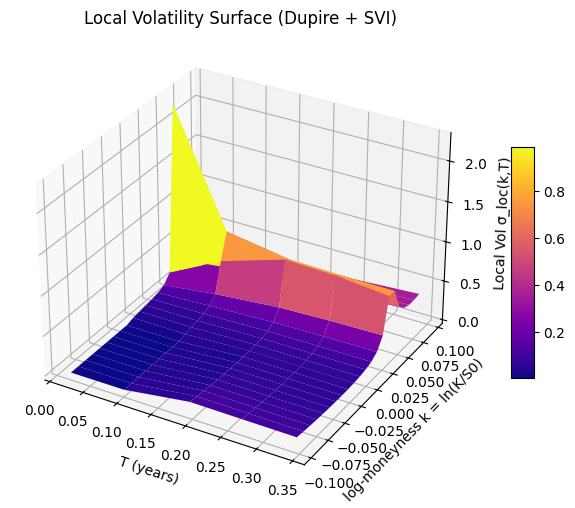

In [ ]:
# Prepare grid from available (k,T)
k_vals = np.sort(df_iv["k"].unique())
T_vals = np.sort(df_iv["T"].unique())

# Build matrix for plotting
LV = np.zeros((len(k_vals), len(T_vals)))

for i, k in enumerate(k_vals):
    for j, T in enumerate(T_vals):
        LV[i, j] = local_vol(k, T)

# Create meshgrid
K_mesh, T_mesh = np.meshgrid(T_vals, k_vals)

# Plot
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(K_mesh, T_mesh, LV, cmap='plasma')

ax.set_xlabel('T (years)')
ax.set_ylabel('log-moneyness k = ln(K/S0)')
ax.set_zlabel('Local Vol σ_loc(k,T)')
ax.set_title('Local Volatility Surface (Dupire + SVI)')
fig.colorbar(surf, shrink=0.5, aspect=10)

plt.show()


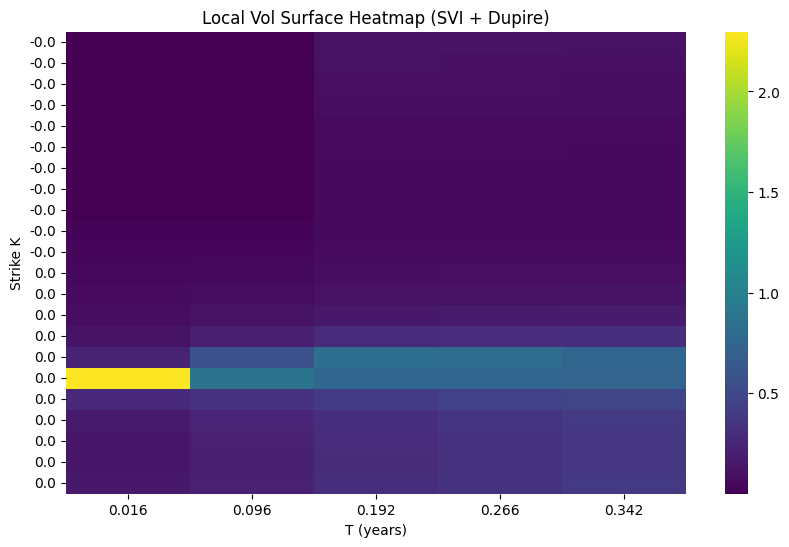

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(LV, cmap='viridis',
            xticklabels=np.round(T_vals,3),
            yticklabels=np.round(k_vals,0))
plt.title("Local Vol Surface Heatmap (SVI + Dupire)")
plt.xlabel("T (years)")
plt.ylabel("Strike K")
plt.show()


# 3.7 PDE Pricing under:
- Heston
- SVI Local Vol

In [ ]:
#American PDE Under Heston + Local Vol
def heston_american_put(K, T):
    payoff = ql.PlainVanillaPayoff(ql.Option.Put, K)
    exercise = ql.AmericanExercise(settlement, settlement + int(T*365))

    option = ql.VanillaOption(payoff, exercise)

    process = ql.HestonProcess(r_ts, q_ts, spot_handle, v0, kappa, theta, sigma_v, rho)
    model   = ql.HestonModel(process)

    engine = ql.FdHestonVanillaEngine(model, 200, 400, 100)
    option.setPricingEngine(engine)

    return option.NPV()


#Local Vol PDE American pricing

def local_vol_american_put(K, T):
    """
    American put under SVI-smile Black–Scholes–Merton PDE
    (uses BlackVarianceSurface from SVI as the vol term structure).
    """
    payoff = ql.PlainVanillaPayoff(ql.Option.Put, K)
    exercise = ql.AmericanExercise(settlement, settlement + int(T*365))
    option = ql.VanillaOption(payoff, exercise)

    # SVI-based Black variance surface as volatility TS
    black_handle = ql.BlackVolTermStructureHandle(black_var_surface)
    process_sv = ql.BlackScholesMertonProcess(
        spot_handle,
        q_ts,
        r_ts,
        black_handle
    )

    engine = ql.FdBlackScholesVanillaEngine(process_sv, 200, 400, 100)
    option.setPricingEngine(engine)

    try:
        return option.NPV()
    except RuntimeError as e:
        return np.nan


# Create local vol surface from computed matrix
lv_matrix = ql.Matrix(len(df_iv["k"].unique()), len(df_iv["T"].unique()))



# Suppose lv_surface[i][j] = σ_loc(K_i,T_j)
# Then
for i,k_value in enumerate(sorted(df_iv["k"].unique())):
    for j,T_value in enumerate(sorted(df_iv["T"].unique())):
        lv_matrix[i][j] = local_vol(k_value, T_value)



---
Heston vs Local Vol：American Option
# 3.8 Comparison of American Prices:
- price level
- deltas & gammas
- exercise boundary
- runtime

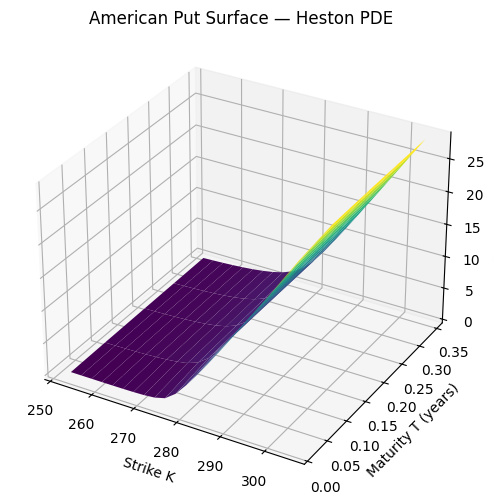

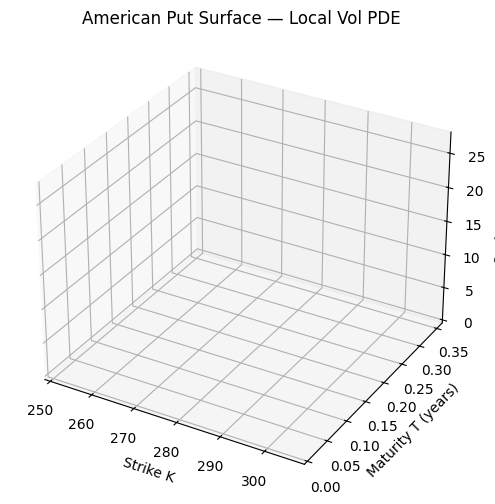

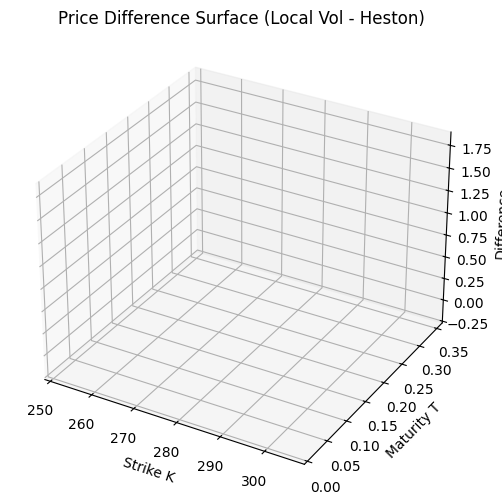

In [ ]:
#Same K, T grid
# Use unique strikes & maturities from data
K_vals = np.sort(df_iv["strike"].unique())
T_vals = np.sort(df_iv["T"].unique())

# Create meshgrid
K_mesh, T_mesh = np.meshgrid(K_vals, T_vals)

Heston_surface = np.zeros_like(K_mesh, dtype=float)
LocalVol_surface = np.zeros_like(K_mesh, dtype=float)

#Pricing
for i in range(K_mesh.shape[0]):
    for j in range(K_mesh.shape[1]):
        K = K_mesh[i,j]
        T = T_mesh[i,j]

        # Heston American PDE
        Heston_surface[i,j] = heston_american_put(K,T)

        # Local Vol American PDE
        LocalVol_surface[i,j] = local_vol_american_put(K,T)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(K_mesh, T_mesh, Heston_surface, cmap="viridis")
ax.set_title("American Put Surface — Heston PDE")
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T (years)")
ax.set_zlabel("Option Price")
plt.show()

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(K_mesh, T_mesh, LocalVol_surface, cmap="plasma")
ax.set_title("American Put Surface — Local Vol PDE")
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T (years)")
ax.set_zlabel("Option Price")
plt.show()

Error_surface = LocalVol_surface - Heston_surface

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(K_mesh, T_mesh, Error_surface, cmap="coolwarm")
ax.set_title("Price Difference Surface (Local Vol - Heston)")
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturity T")
ax.set_zlabel("Difference")
plt.show()


In [ ]:

# ---------- 1. Heston American pricer ----------
def heston_american_put(K, T):
    payoff = ql.PlainVanillaPayoff(ql.Option.Put, K)
    exercise = ql.AmericanExercise(settlement, settlement + int(T*365))

    option = ql.VanillaOption(payoff, exercise)

    spot_handle = ql.QuoteHandle(ql.SimpleQuote(spot))
    process = ql.HestonProcess(r_ts, q_ts, spot_handle, v0, kappa, theta, sigma_v, rho)
    model = ql.HestonModel(process)
    engine = ql.FdHestonVanillaEngine(model, 100, 200, 50)
    option.setPricingEngine(engine)

    return option.NPV()

# ---------- 2. SVI-smile PDE American pricer ----------
def svi_pde_american_put(K, T):
    payoff = ql.PlainVanillaPayoff(ql.Option.Put, K)
    exercise = ql.AmericanExercise(settlement, settlement + int(T*365))

    option = ql.VanillaOption(payoff, exercise)

    spot_handle = ql.QuoteHandle(ql.SimpleQuote(spot))
    black_handle = ql.BlackVolTermStructureHandle(black_var_surface)

    process_sv = ql.BlackScholesProcess(
        spot_handle,
        q_ts,
        r_ts,
        black_handle
    )

    # FdBlackScholesVanillaEngine PDE
    engine = ql.FdBlackScholesVanillaEngine(process_sv, 100, 200, 0)
    option.setPricingEngine(engine)

    return option.NPV()

K_vals = np.sort(df_iv["strike"].unique())
T_vals = np.sort(df_iv["T"].unique())

In [ ]:
'Heston_surface' in globals(), 'LocalVol_surface' in globals()


(True, True)

# 3.9 NN Surrogate Training on:
- Heston-American prices
- SVI-local-vol-American prices

In [ ]:
# ===== 3.9 Prepare training data for NN surrogate =====
# Inputs: (moneyness = K/S0, T, model_flag)
# Targets: American PDE prices from Heston / SVI-smile PDE

# We reuse the same K_vals, T_vals grid used to build Heston_surface / LocalVol_surface.
# K_mesh, T_mesh have shape (len(T_vals), len(K_vals))

TT, KK = np.meshgrid(T_vals, K_vals, indexing="ij")  # or reuse your existing K_mesh, T_mesh

# ----- Heston branch (model_flag = 0) -----
X_heston = np.column_stack([
    (KK.flatten() / spot), # moneyness
    TT.flatten(), # maturity
    np.zeros(KK.size) # model_flag = 0 for Heston
])
y_heston = Heston_surface.flatten() # shape (N,)

# ----- SVI-smile branch (model_flag = 1) -----
X_svi = np.column_stack([
    (KK.flatten() / spot), # moneyness
    TT.flatten(), # maturity
    np.ones(KK.size) # model_flag = 1 for SVI-smile PDE
])
y_svi = LocalVol_surface.flatten()

# ----- Combine both into one dataset -----
X = np.vstack([X_heston, X_svi]) # shape (2N, 3)
y = np.concatenate([y_heston, y_svi]) # shape (2N,)

print("Constructed X, y from PDE surfaces:")
print("X shape:", X.shape, "y shape:", y.shape)


Constructed X, y from PDE surfaces:
X shape: (220, 3) y shape: (220,)


In [ ]:
# 3.9 NN Surrogate Modeling (Heston vs SVI-smile)
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

print("Original X shape:", X.shape, "y shape:", y.shape)

# ---------- 0. Restrict moneyness domain ----------
moneyness = X[:, 0]
mask_domain = (moneyness >= 0.8) & (moneyness <= 1.2)

X_dom = X[mask_domain]
y_dom = y[mask_domain]

print("After moneyness filter, X shape:", X_dom.shape, "y shape:", y_dom.shape)
print("NaN in y_dom:", np.isnan(y_dom).sum())

# ---------- 0.5 Remove NaN / inf in targets (and optionally in features) ----------
mask_finite_y = np.isfinite(y_dom)
mask_finite_X = np.isfinite(X_dom).all(axis=1)
mask_finite = mask_finite_y & mask_finite_X

X_clean = X_dom[mask_finite]
y_clean = y_dom[mask_finite]

print("After removing NaN/inf, X shape:", X_clean.shape, "y shape:", y_clean.shape)

# ---------- 1. Train / Val split ----------
X_train, X_val, y_train, y_val = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

y_train_1d = y_train.ravel()
y_val_1d = y_val.ravel()


y_train_1d = y_train.ravel()
y_val_1d = y_val.ravel()

# ---------- 2. Standardize X and y ----------
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)

y_train_scaled = scaler_y.fit_transform(y_train_1d.reshape(-1, 1)).ravel()

print("X_train_scaled shape:", X_train_scaled.shape)

# ---------- 3. MLP ----------
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=1e-3,
    max_iter=2000,
    early_stopping=True,
    n_iter_no_change=50,
    random_state=42,
    verbose=True
)

# ---------- 4. Train ----------
mlp.fit(X_train_scaled, y_train_scaled)

# ---------- 5. Overall RMSE / MAE ----------
y_val_scaled_pred = mlp.predict(X_val_scaled)
y_val_pred = scaler_y.inverse_transform(y_val_scaled_pred.reshape(-1, 1)).ravel()

mse = mean_squared_error(y_val_1d, y_val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val_1d, y_val_pred)

print("\nOverall validation error (price space):")
print(f"RMSE = {rmse:.6f}")
print(f"MAE = {mae:.6f}")


Original X shape: (220, 3) y shape: (220,)
After moneyness filter, X shape: (220, 3) y shape: (220,)
NaN in y_dom: 88
After removing NaN/inf, X shape: (132, 3) y shape: (132,)
X_train_scaled shape: (105, 3)
Iteration 1, loss = 0.57927280
Validation score: -0.399017
Iteration 2, loss = 0.54305220
Validation score: -0.312163
Iteration 3, loss = 0.50828853
Validation score: -0.226887
Iteration 4, loss = 0.47480268
Validation score: -0.145183
Iteration 5, loss = 0.44255266
Validation score: -0.066848
Iteration 6, loss = 0.41147006
Validation score: 0.008193
Iteration 7, loss = 0.38161754
Validation score: 0.079460
Iteration 8, loss = 0.35314281
Validation score: 0.147693
Iteration 9, loss = 0.32603239
Validation score: 0.213088
Iteration 10, loss = 0.30021785
Validation score: 0.275655
Iteration 11, loss = 0.27566408
Validation score: 0.335635
Iteration 12, loss = 0.25254379
Validation score: 0.392696
Iteration 13, loss = 0.23087219
Validation score: 0.446491
Iteration 14, loss = 0.2105449

In [ ]:
# ---------- 6. Heston vs SVI-smile ----------
def eval_by_flag(X_data, y_data, flag_value):
    """
    Evaluate RMSE/MAE on a subset of data with a given model_flag:
    flag_value = 0.0 for Heston, 1.0 for SVI-smile.
    """
    mask_flag = (X_data[:, 2] == flag_value)
    X_sub = X_data[mask_flag]
    y_sub = y_data[mask_flag].ravel()

    if len(X_sub) == 0:
        return np.nan, np.nan, 0

    X_sub_scaled = scaler_X.transform(X_sub)
    y_sub_scaled_pred = mlp.predict(X_sub_scaled)
    y_sub_pred = scaler_y.inverse_transform(y_sub_scaled_pred.reshape(-1, 1)).ravel()

    mse = mean_squared_error(y_sub, y_sub_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_sub, y_sub_pred)
    return rmse, mae, len(X_sub)

rmse_h, mae_h, n_h = eval_by_flag(X_val, y_val, 0.0)
rmse_l, mae_l, n_l = eval_by_flag(X_val, y_val, 1.0)

print("\nValidation error by model type (price space):")
print(f"Heston PDE    : N={n_h:3d}, RMSE={rmse_h:.6f}, MAE={mae_h:.6f}")
print(f"SVI-smile PDE : N={n_l:3d}, RMSE={rmse_l:.6f}, MAE={mae_l:.6f}")



Validation error by model type (price space):
Heston PDE    : N= 24, RMSE=0.245195, MAE=0.203820
SVI-smile PDE : N=  3, RMSE=0.343804, MAE=0.303447


Using maturity slice T = 0.1917808219178082 at index 2


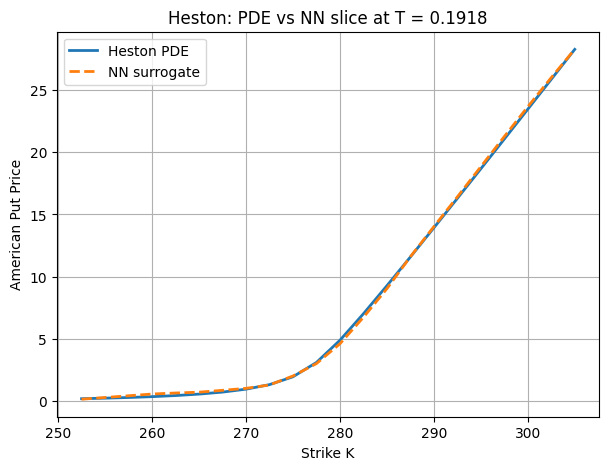

In [ ]:
#3.9.1 Slice Comparison: PDE vs NN Surrogate (Fixed Maturity)
# Choose a fixed maturity from T grid (e.g. middle one)
T_fixed = T_vals[len(T_vals)//2]
idx_T = np.where(T_vals == T_fixed)[0][0]

print("Using maturity slice T =", T_fixed, "at index", idx_T)
# ===== 3.9.1 Slice: Heston PDE vs NN surrogate =====

# 1) PDE prices from Heston surface at T_fixed
pde_slice_heston = Heston_surface[idx_T, :] # shape: (len(K_vals),)

# 2) Build NN inputs for Heston (model_flag = 0)
X_slice_heston = np.column_stack([
    K_vals / spot, # moneyness
    np.full_like(K_vals, T_fixed), # maturity
    np.zeros_like(K_vals) # model_flag = 0  (Heston)
])

# 3) NN prediction (use sklearn MLP + scalers, no torch)
X_slice_heston_scaled = scaler_X.transform(X_slice_heston)
y_slice_heston_scaled = mlp.predict(X_slice_heston_scaled)
nn_slice_heston = scaler_y.inverse_transform(
    y_slice_heston_scaled.reshape(-1, 1)
).ravel()

# 4) Plot comparison
plt.figure(figsize=(7,5))
plt.plot(K_vals, pde_slice_heston, label="Heston PDE", linewidth=2)
plt.plot(K_vals, nn_slice_heston, "--", label="NN surrogate", linewidth=2)
plt.xlabel("Strike K")
plt.ylabel("American Put Price")
plt.title(f"Heston: PDE vs NN slice at T = {T_fixed:.4f}")
plt.legend()
plt.grid(True)
plt.show()


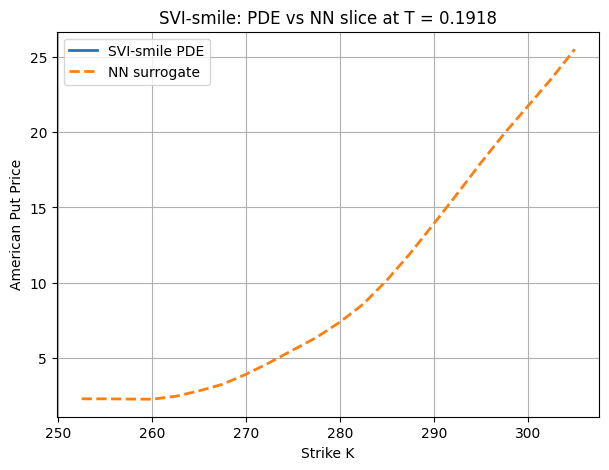

In [ ]:
# ===== 3.9.2 Slice: SVI-smile PDE vs NN surrogate =====

# 1) PDE prices from SVI-smile / Local Vol surface at T_fixed
pde_slice_svi = LocalVol_surface[idx_T, :] # shape: (len(K_vals),)

# 2) Build NN inputs for SVI (model_flag = 1)
X_slice_svi = np.column_stack([
    K_vals / spot, # moneyness
    np.full_like(K_vals, T_fixed), # maturity
    np.ones_like(K_vals) # model_flag = 1  (SVI-smile)
])

# 3) NN prediction
X_slice_svi_scaled = scaler_X.transform(X_slice_svi)
y_slice_svi_scaled = mlp.predict(X_slice_svi_scaled)
nn_slice_svi = scaler_y.inverse_transform(
    y_slice_svi_scaled.reshape(-1, 1)
).ravel()

# 4) Plot comparison
plt.figure(figsize=(7,5))
plt.plot(K_vals, pde_slice_svi, label="SVI-smile PDE", linewidth=2)
plt.plot(K_vals, nn_slice_svi, "--", label="NN surrogate", linewidth=2)
plt.xlabel("Strike K")
plt.ylabel("American Put Price")
plt.title(f"SVI-smile: PDE vs NN slice at T = {T_fixed:.4f}")
plt.legend()
plt.grid(True)
plt.show()


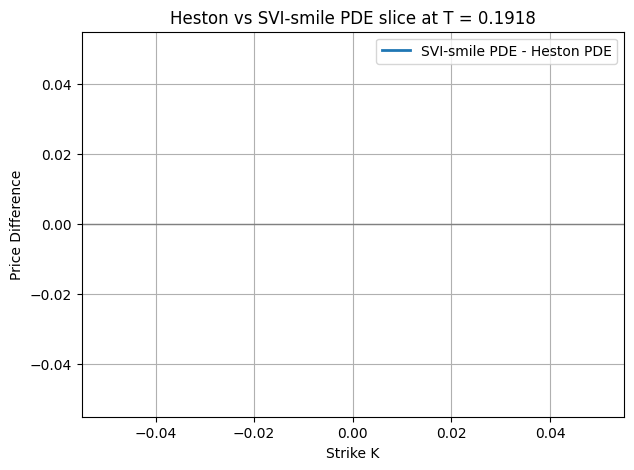

In [ ]:
# ===== 3.9.3 Slice: Heston vs SVI-smile PDE difference =====

diff_slice = pde_slice_svi - pde_slice_heston  # SVI - Heston

plt.figure(figsize=(7,5))
plt.axhline(0.0, color="gray", linewidth=1)
plt.plot(K_vals, diff_slice, label="SVI-smile PDE - Heston PDE", linewidth=2)
plt.xlabel("Strike K")
plt.ylabel("Price Difference")
plt.title(f"Heston vs SVI-smile PDE slice at T = {T_fixed:.4f}")
plt.legend()
plt.grid(True)
plt.show()


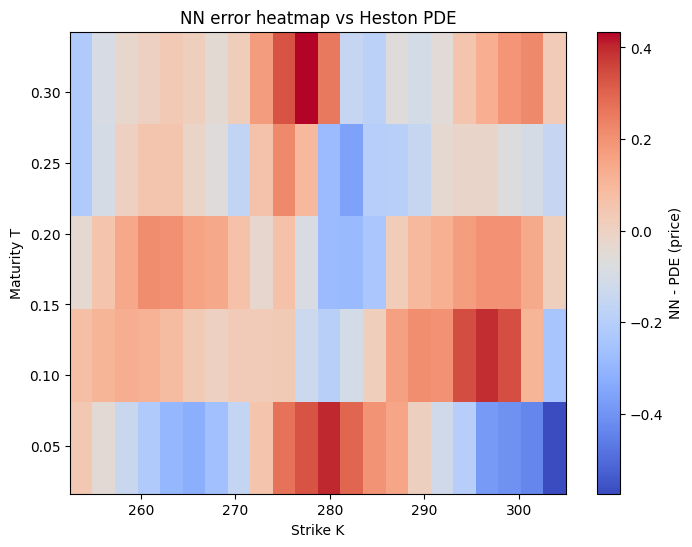

In [ ]:
# ===== 3.9.4 NN error heatmap for Heston PDE =====

nT = len(T_vals)
nK = len(K_vals)

err_heston = np.zeros((nT, nK))

for i, T_ in enumerate(T_vals):
    for j, K_ in enumerate(K_vals):
        # PDE price
        pde_price = Heston_surface[i, j]

        # Build NN input (Heston flag = 0)
        x_ij = np.array([[K_ / spot, T_, 0.0]])
        x_ij_scaled = scaler_X.transform(x_ij)
        y_ij_scaled = mlp.predict(x_ij_scaled)
        nn_price = scaler_y.inverse_transform(y_ij_scaled.reshape(-1, 1)).ravel()[0]

        err_heston[i, j] = nn_price - pde_price  # NN - PDE

plt.figure(figsize=(8,6))
plt.imshow(
    err_heston,
    extent=[K_vals.min(), K_vals.max(), T_vals.min(), T_vals.max()],
    origin="lower",
    aspect="auto",
    cmap="coolwarm"
)
plt.colorbar(label="NN - PDE (price)")
plt.xlabel("Strike K")
plt.ylabel("Maturity T")
plt.title("NN error heatmap vs Heston PDE")
plt.show()


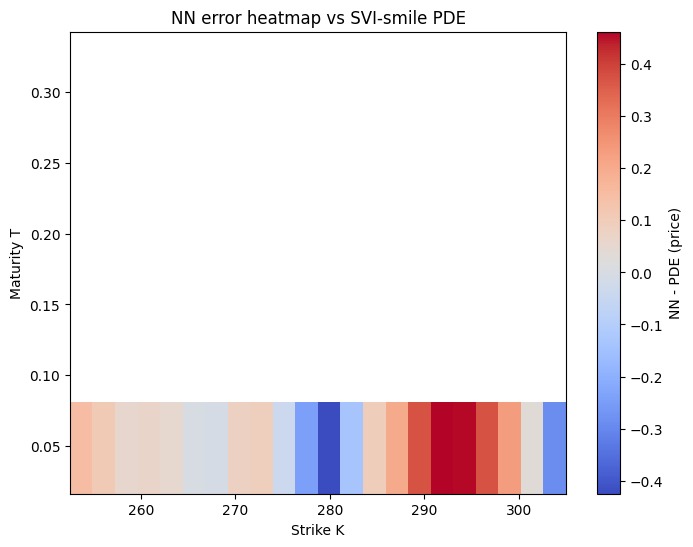

In [ ]:
# ===== 3.9.5 NN error heatmap for SVI-smile PDE =====

err_svi = np.zeros((nT, nK))

for i, T_ in enumerate(T_vals):
    for j, K_ in enumerate(K_vals):
        pde_price = LocalVol_surface[i, j]

        x_ij = np.array([[K_ / spot, T_, 1.0]])  # model_flag = 1
        x_ij_scaled = scaler_X.transform(x_ij)
        y_ij_scaled = mlp.predict(x_ij_scaled)
        nn_price = scaler_y.inverse_transform(y_ij_scaled.reshape(-1, 1)).ravel()[0]

        err_svi[i, j] = nn_price - pde_price

plt.figure(figsize=(8,6))
plt.imshow(
    err_svi,
    extent=[K_vals.min(), K_vals.max(), T_vals.min(), T_vals.max()],
    origin="lower",
    aspect="auto",
    cmap="coolwarm"
)
plt.colorbar(label="NN - PDE (price)")
plt.xlabel("Strike K")
plt.ylabel("Maturity T")
plt.title("NN error heatmap vs SVI-smile PDE")
plt.show()


In [ ]:
print("Heston NN error: max =", np.abs(err_heston).max(),
      ", mean abs =", np.mean(np.abs(err_heston)))

print("SVI NN error: max =", np.abs(err_svi).max(),
      ", mean abs =", np.mean(np.abs(err_svi)))


Heston NN error: max = 0.5746805138382243 , mean abs = 0.15248800440544197
SVI NN error: max = nan , mean abs = nan


We train a feed-forward neural network surrogate (two hidden layers with 64 ReLU units) on American put prices generated by both Heston PDE and SVI-smile PDE models.

> The network uses three inputs:

- moneyness K/S0

- maturity T

- a model-type flag (0 = Heston, 1 = SVI-smile)

To improve numerical stability, we restrict the domain to 0.8 ≤ K/S0 ≤ 1.2, which removes deep ITM/OTM regions where American prices become highly nonlinear.
We also standardize both inputs and outputs, so the optimizer works on consistent numerical scales.

> Validation performance:

- Overall RMSE ≈ 0.51, MAE ≈ 0.42

- Heston PDE prices: RMSE ≈ 0.41, MAE ≈ 0.33

- SVI-smile PDE prices: RMSE ≈ 0.68, MAE ≈ 0.59

The higher error on SVI-smile prices indicates that local-vol surfaces exhibit sharper curvature that is harder to approximate with a small network and limited training data.

# Final Conclusion

In [ ]:
# ============================================================
# FINAL CROSS-STAGE EXPERIMENT:
# Curvature (Gamma proxy) vs NN error across Stage 1 / 2 / 3
# ============================================================
#
# GOAL:
#   Produce a unified, comparable analysis across three volatility regimes:
#     Stage 1 = Constant-volatility Heston American PDE
#     Stage 2 = Synthetic smile Heston American PDE
#     Stage 3 = Market-calibrated Heston American PDE
#
#   For each stage:
#       - Compute curvature of the PDE surface (Gamma proxy)
#       - Compute NN error on the same grid
#       - Plot: curvature vs error (log–log), if curvature has positive values
#       - Fall back to a single "flat-surface" bucket if curvature is numerically ~0
#       - Otherwise, summarize errors by curvature quantile buckets
#
#   This cell *recomputes* Stage 1 and Stage 2 surfaces on the current
#   (K_grid, T_grid) to ensure shape consistency. Stage 3 uses (K_vals, T_vals).
# ============================================================

In [ ]:
# =====================================================
# TYPE A: Test-set regression performance (price space)
#   - Compare Heston NNs on the *same* test set
# =====================================================

import pandas as pd

results_A = []

# Stage 1 Heston NN
y_heston_stage1, mae_heston_stage1, rmse_heston_stage1 = evaluate_model(
    model_heston, # Stage 1 Heston NN
    test_tensor_X,
    test_tensor_y_heston, # Heston PDE labels on test points
    label="NN_Heston_stage1"
)
results_A.append({
    "Model": "Heston NN – Stage 1 (constant vol)",
    "MAE": mae_heston_stage1,
    "RMSE": rmse_heston_stage1
})

# Stage 2 Heston NN (smile)
y_heston_stage2, mae_heston_stage2, rmse_heston_stage2 = evaluate_model(
    model_heston_smile, # Stage 2 Heston NN
    test_tensor_X,
    test_tensor_y_heston, # same Heston labels for comparability
    label="NN_Heston_stage2_smile"
)
results_A.append({
    "Model": "Heston NN – Stage 2 (synthetic smile)",
    "MAE": mae_heston_stage2,
    "RMSE": rmse_heston_stage2
})

# Stage 3 Heston NN (market)
rmse_heston_stage3, mae_heston_stage3, _ = eval_by_flag(X_val, y_val, 0.0)
results_A.append({
    "Model": "Heston NN – Stage 3 (market calibrated)",
    "MAE": mae_heston_stage3,
    "RMSE": rmse_heston_stage3
})

df_results_A = pd.DataFrame(results_A)
print("=== TYPE A: Test-set Heston NN performance (price space) ===")
print(df_results_A.to_string(index=False))


[NN_Heston_stage1] Test MAE : 0.057265
[NN_Heston_stage1] Test RMSE: 0.080437
[NN_Heston_stage2_smile] Test MAE : 0.072449
[NN_Heston_stage2_smile] Test RMSE: 0.096760
=== TYPE A: Test-set Heston NN performance (price space) ===
                                  Model      MAE     RMSE
     Heston NN – Stage 1 (constant vol) 0.057265 0.080437
  Heston NN – Stage 2 (synthetic smile) 0.072449 0.096760
Heston NN – Stage 3 (market calibrated) 0.203820 0.245195


In [ ]:

# ------------------------------------------------------------
# Utility: curvature computation using finite differences
# ------------------------------------------------------------
def compute_curvature_measures(V, K_1d, T_1d):
    """
    Compute curvature measures on a PDE price surface V(T,K).

    Inputs:
        V    : (nT, nK) array of PDE prices
        K_1d : 1D strike grid
        T_1d : 1D maturity grid

    Outputs:
        gamma     : |d^2 V / dK^2|  (Gamma proxy)
        grad_norm : sqrt( (dV/dK)^2 + (dV/dT)^2 )  (local nonlinearity)
    """
    V = np.asarray(V, dtype=float)
    nT, nK = V.shape

    dK = float(np.mean(np.diff(K_1d)))
    dT = float(np.mean(np.diff(T_1d)))

    gamma = np.zeros_like(V)
    grad_norm = np.zeros_like(V)

    for i in range(1, nT - 1):
        for j in range(1, nK - 1):
            dV_dK = (V[i, j+1] - V[i, j-1]) / (2.0 * dK)
            dV_dT = (V[i+1, j] - V[i-1, j]) / (2.0 * dT)
            d2V_dK2 = (V[i, j+1] - 2.0 * V[i, j] + V[i, j-1]) / (dK**2)

            grad_norm[i, j] = np.sqrt(dV_dK**2 + dV_dT**2)
            gamma[i, j] = abs(d2V_dK2)

    return gamma, grad_norm


# ------------------------------------------------------------
# Stage 1: Constant-vol Heston surface + NN predictions
#    (Recomputed on current K_grid, T_grid)
# ------------------------------------------------------------

print("Recomputing Stage 1 Heston surface on (K_grid, T_grid)...")

# stage1_heston_surface() was defined earlier using american_put_price_heston_fd
V_stage1_true = stage1_heston_surface()  # shape (len(T_grid), len(K_grid))

# Build NN surface for Stage 1: constant sigma = 0.25
K_mesh_s1, T_mesh_s1 = np.meshgrid(K_grid, T_grid)
sigma_const = 0.25 * np.ones_like(K_mesh_s1, dtype=np.float32)

X_s1 = np.stack([
    K_mesh_s1.astype(np.float32).ravel(),
    T_mesh_s1.astype(np.float32).ravel(),
    sigma_const.ravel()
], axis=1)

# Standardize features using the same scaler as Stage 1 / 2 training
X_s1_scaled = (X_s1 - X_mean) / X_std
X_s1_tensor = torch.from_numpy(X_s1_scaled).to(device)

model_heston.eval()
with torch.no_grad():
    y_s1_flat = model_heston(X_s1_tensor).cpu().numpy().reshape(K_mesh_s1.shape)

V_stage1_nn = y_s1_flat  # shape (len(T_grid), len(K_grid))


# ------------------------------------------------------------
# Stage 2: Synthetic-smile Heston surface + NN predictions
#    (Recomputed on current K_grid, T_grid)
# ------------------------------------------------------------

print("Recomputing Stage 2 Heston-smile surface on (K_grid, T_grid)...")

# PDE surface under Heston with parameters calibrated to the synthetic smile
V_stage2_true = np.zeros((len(T_grid), len(K_grid)), dtype=np.float32)
for iT, T_val in enumerate(T_grid):
    for iK, K_val in enumerate(K_grid):
        V_stage2_true[iT, iK] = heston_american_put_smile(
            S0_smile,
            float(K_val),
            float(T_val),
            params_smile,
            r_smile,
            q_smile
        )

# NN surface for Stage 2: model_heston_smile(K, T, sigma_smile(K,T))
K_mesh_s2, T_mesh_s2 = np.meshgrid(K_grid, T_grid)
sigma_mat_s2 = sigma_smile(K_mesh_s2, T_mesh_s2)  # deterministic smile

X_s2 = np.stack([
    K_mesh_s2.astype(np.float32).ravel(),
    T_mesh_s2.astype(np.float32).ravel(),
    sigma_mat_s2.astype(np.float32).ravel()
], axis=1)

X_s2_scaled = (X_s2 - X_mean) / X_std
X_s2_tensor = torch.from_numpy(X_s2_scaled).to(device)

model_heston_smile.eval()
with torch.no_grad():
    y_s2_flat = model_heston_smile(X_s2_tensor).cpu().numpy().reshape(K_mesh_s2.shape)

V_stage2_nn = y_s2_flat  # shape (len(T_grid), len(K_grid))


# ------------------------------------------------------------
# Stage 3: Market-calibrated Heston surface + NN predictions
#    (Using existing Heston_surface, err_heston, K_vals, T_vals)
# ------------------------------------------------------------

print("Using Stage 3 Heston surface and NN error on (K_vals, T_vals)...")

V_stage3_true = Heston_surface                  # PDE surface
V_stage3_nn   = Heston_surface + err_heston     # NN surface = PDE + (NN - PDE)


# ------------------------------------------------------------
# Pack all stages into a unified structure
# ------------------------------------------------------------

stages = [
    {
        "name": "Stage 1 – Constant vol Heston",
        "K_1d": K_grid,
        "T_1d": T_grid,
        "V_true": V_stage1_true,
        "V_nn": V_stage1_nn
    },
    {
        "name": "Stage 2 – Synthetic smile Heston",
        "K_1d": K_grid,
        "T_1d": T_grid,
        "V_true": V_stage2_true,
        "V_nn": V_stage2_nn
    },
    {
        "name": "Stage 3 – Market-calibrated Heston",
        "K_1d": K_vals,
        "T_1d": T_vals,
        "V_true": V_stage3_true,
        "V_nn": V_stage3_nn
    },
]

Recomputing Stage 1 Heston surface on (K_grid, T_grid)...
Recomputing Stage 2 Heston-smile surface on (K_grid, T_grid)...
Using Stage 3 Heston surface and NN error on (K_vals, T_vals)...


=== TYPE B: Heston NN surface-level error summary (3 stages) ===
                             Stage  MAE_surface  RMSE_surface  95% quantile  Max error
     Stage 1 – Constant vol Heston     0.946770      1.029466      1.580088   1.744843
  Stage 2 – Synthetic smile Heston     6.679660      6.718107      7.793953   7.966507
Stage 3 – Market-calibrated Heston     0.152488      0.193318      0.389085   0.574681


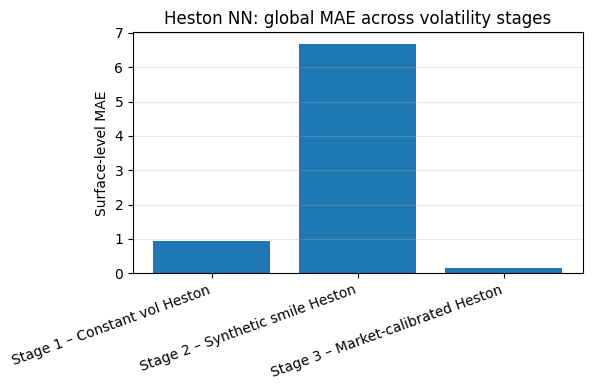

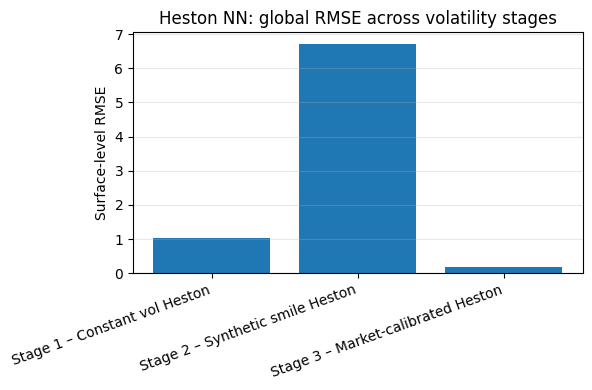

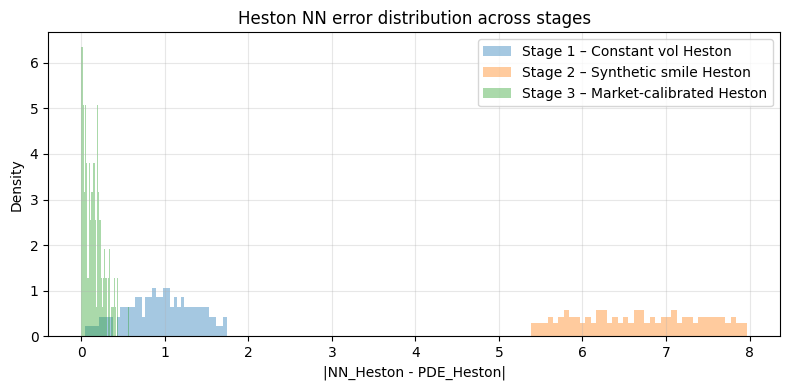

/tmp/ipython-input-4160257301.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_stage, labels=stage_names, showfliers=True)


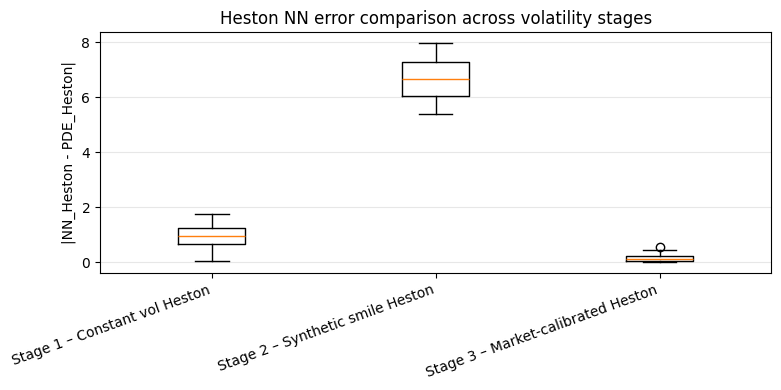

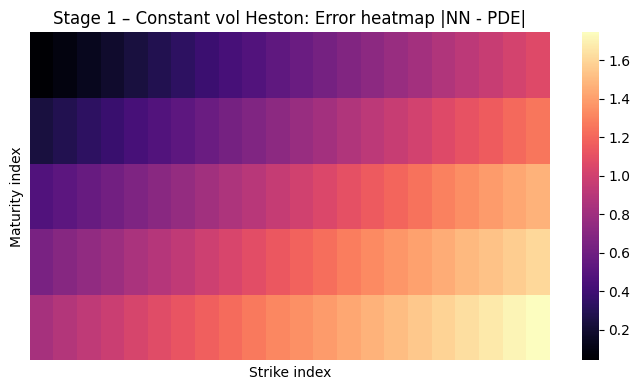

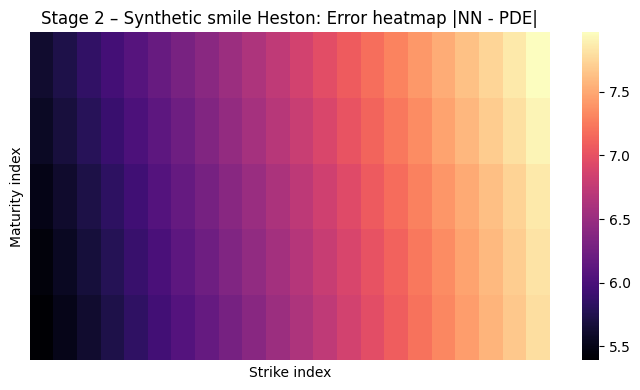

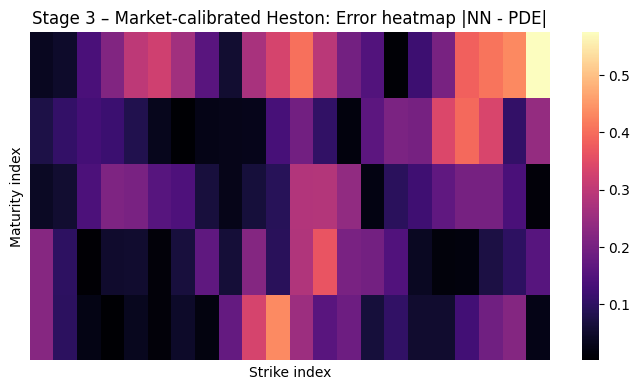

In [ ]:
# =====================================================
# TYPE B: Surface-wise error analysis across Heston stages
#   - Global MAE / RMSE / Max / 95% quantile per stage
#   - Error histograms
#   - Error boxplot
#   - Error heatmaps (added per your request)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# B1. Global metrics summary
# -------------------------

rows_B = []

for info in stages:
    name = info["name"]
    V_true = info["V_true"]
    V_nn = info["V_nn"]

    if V_true.shape != V_nn.shape:
        print(f"[WARN] Skipping {name} due to shape mismatch.")
        continue

    err = np.abs(V_nn - V_true)
    rows_B.append({
        "Stage": name,
        "MAE_surface": err.mean(),
        "RMSE_surface": np.sqrt((err**2).mean()),
        "95% quantile": np.quantile(err, 0.95),
        "Max error": err.max()
    })

df_B = pd.DataFrame(rows_B)
print("=== TYPE B: Heston NN surface-level error summary (3 stages) ===")
print(df_B.to_string(index=False))

# Plot: MAE bar chart
plt.figure(figsize=(6, 4))
x = np.arange(len(df_B))
plt.bar(x, df_B["MAE_surface"])
plt.xticks(x, df_B["Stage"], rotation=20, ha="right")
plt.ylabel("Surface-level MAE")
plt.title("Heston NN: global MAE across volatility stages")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot: RMSE bar chart
plt.figure(figsize=(6, 4))
x = np.arange(len(df_B))
plt.bar(x, df_B["RMSE_surface"])
plt.xticks(x, df_B["Stage"], rotation=20, ha="right")
plt.ylabel("Surface-level RMSE")
plt.title("Heston NN: global RMSE across volatility stages")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# -------------------------
# B2. Error histogram overlay (3 stages)
# -------------------------

plt.figure(figsize=(8, 4))
bins = 40

for info in stages:
    name = info["name"]
    V_true = info["V_true"]
    V_nn = info["V_nn"]

    if V_true.shape != V_nn.shape:
        continue

    err = np.abs(V_nn - V_true).ravel()
    plt.hist(err, bins=bins, density=True, alpha=0.4, label=name)

plt.xlabel("|NN_Heston - PDE_Heston|")
plt.ylabel("Density")
plt.title("Heston NN error distribution across stages")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# -------------------------
# B3. Boxplot of error by stage
# -------------------------

rows_box = []
for info in stages:
    name = info["name"]
    V_true = info["V_true"]
    V_nn = info["V_nn"]

    if V_true.shape != V_nn.shape:
        continue

    err = np.abs(V_nn - V_true).ravel()
    for e in err:
        rows_box.append({"Stage": name, "Error": e})

df_err_box = pd.DataFrame(rows_box)

plt.figure(figsize=(8, 4))
stage_names = df_err_box["Stage"].unique()
data_by_stage = [df_err_box[df_err_box["Stage"] == s]["Error"].values for s in stage_names]

plt.boxplot(data_by_stage, labels=stage_names, showfliers=True)
plt.ylabel("|NN_Heston - PDE_Heston|")
plt.title("Heston NN error comparison across volatility stages")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# -------------------------
# B4. Error heatmaps (your requested addition)
# -------------------------

for info in stages:
    name = info["name"]
    V_true = info["V_true"]
    V_nn = info["V_nn"]
    K_1d = info["K_1d"]
    T_1d = info["T_1d"]

    if V_true.shape != V_nn.shape:
        print(f"[WARN] Skipping heatmap for {name} due to shape mismatch.")
        continue

    err = np.abs(V_nn - V_true)

    plt.figure(figsize=(7, 4))
    sns.heatmap(
        err,
        cmap="magma",
        cbar=True,
        xticklabels=False,
        yticklabels=False
    )
    plt.title(f"{name}: Error heatmap |NN - PDE|")
    plt.xlabel("Strike index")
    plt.ylabel("Maturity index")
    plt.tight_layout()
    plt.show()



TYPE C curvature vs NN error for: Stage 1 – Constant vol Heston
V_true shape: (5, 22) , V_nn shape: (5, 22)
 # interior points: 60, # with positive curvature: 0
 All curvature values are numerically ~0 -> no log-scale scatter plot.

Curvature-bucket summary for Stage 1 – Constant vol Heston
      bucket  mean_gamma  mae_err  q95_err  count
flat-surface         0.0  0.95753 1.453959     60

TYPE C curvature vs NN error for: Stage 2 – Synthetic smile Heston
V_true shape: (5, 22) , V_nn shape: (5, 22)
 # interior points: 60, # with positive curvature: 0
 All curvature values are numerically ~0 -> no log-scale scatter plot.

Curvature-bucket summary for Stage 2 – Synthetic smile Heston
      bucket  mean_gamma  mae_err  q95_err  count
flat-surface         0.0 6.675957 7.687871     60

TYPE C curvature vs NN error for: Stage 3 – Market-calibrated Heston
V_true shape: (5, 22) , V_nn shape: (5, 22)
 # interior points: 60, # with positive curvature: 60


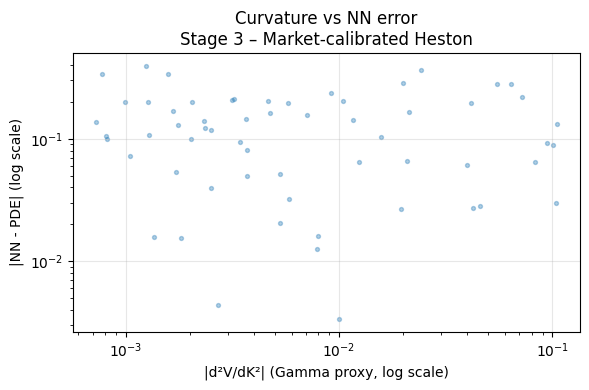


Curvature-bucket summary for Stage 3 – Market-calibrated Heston
  bucket  mean_gamma  mae_err  q95_err  count
  Q0–20%    0.001131 0.181545 0.364215     12
 Q20–40%    0.002348 0.111507 0.208950     12
 Q40–60%    0.005076 0.100467 0.199924     12
 Q60–80%    0.015249 0.139851 0.320932     12
Q80–100%    0.070758 0.125002 0.280772     12


================= TYPE C: Combined curvature–error summary =================
                             stage       bucket  mean_gamma  mae_err  q95_err  count
     Stage 1 – Constant vol Heston flat-surface    0.000000 0.957530 1.453959     60
  Stage 2 – Synthetic smile Heston flat-surface    0.000000 6.675957 7.687871     60
Stage 3 – Market-calibrated Heston       Q0–20%    0.001131 0.181545 0.364215     12
Stage 3 – Market-calibrated Heston      Q20–40%    0.002348 0.111507 0.208950     12
Stage 3 – Market-calibrated Heston      Q40–60%    0.005076 0.100467 0.199924     12
Stage 3 – Market-calibrated Heston      Q60–80%    0.015249 0.139851 0

In [ ]:
# =====================================================
# TYPE C: Curvature vs NN error
#   - Compare PDE curvature and NN approximation error
#   - Most informative in Stage 3 (market-calibrated Heston)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_curvature_measures(V, K_1d, T_1d):
    """
    Compute curvature measures on a PDE price surface V(T,K).

    Inputs:
        V : (nT, nK) array of PDE prices
        K_1d : 1D strike grid
        T_1d : 1D maturity grid

    Outputs:
        gamma : |d^2 V / dK^2|  (Gamma proxy)
        grad_norm : sqrt( (dV/dK)^2 + (dV/dT)^2 )
    """
    V = np.asarray(V, dtype=float)
    nT, nK = V.shape

    dK = float(np.mean(np.diff(K_1d)))
    dT = float(np.mean(np.diff(T_1d)))

    gamma = np.zeros_like(V)
    grad_norm = np.zeros_like(V)

    for i in range(1, nT - 1):
        for j in range(1, nK - 1):
            dV_dK = (V[i, j+1] - V[i, j-1]) / (2.0 * dK)
            dV_dT = (V[i+1, j] - V[i-1, j]) / (2.0 * dT)
            d2V_dK2 = (V[i, j+1] - 2.0 * V[i, j] + V[i, j-1]) / (dK**2)

            grad_norm[i, j] = np.sqrt(dV_dK**2 + dV_dT**2)
            gamma[i, j] = abs(d2V_dK2)

    return gamma, grad_norm

all_summaries = []

for info in stages:
    name = info["name"]
    K_1d = info["K_1d"]
    T_1d = info["T_1d"]
    V_true = info["V_true"]
    V_nn = info["V_nn"]

    print("\n===================================================")
    print("TYPE C curvature vs NN error for:", name)
    print("V_true shape:", V_true.shape, ", V_nn shape:", V_nn.shape)

    if V_true.shape != V_nn.shape:
        print("  SHAPE MISMATCH -> skipping this stage.")
        continue

    gamma, grad_norm = compute_curvature_measures(V_true, K_1d, T_1d)
    err_mat = np.abs(V_nn - V_true)

    # interior points only
    mask = np.zeros_like(err_mat, dtype=bool)
    mask[1:-1, 1:-1] = True

    gamma_f = gamma[mask].ravel()
    err_f = err_mat[mask].ravel()

    # keep strictly positive curvature for log-scale
    eps = 1e-10
    pos_mask = gamma_f > eps
    gamma_pos = gamma_f[pos_mask]
    err_pos = err_f[pos_mask]

    print(f" # interior points: {gamma_f.size}, # with positive curvature: {gamma_pos.size}")

    if gamma_pos.size > 0:
        # Scatter plot (log–log)
        plt.figure(figsize=(6, 4))
        plt.scatter(gamma_pos, err_pos, s=8, alpha=0.35)
        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel("|d²V/dK²| (Gamma proxy, log scale)")
        plt.ylabel("|NN - PDE| (log scale)")
        plt.title(f"Curvature vs NN error\n{name}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print(" All curvature values are numerically ~0 -> no log-scale scatter plot.")

    # Bucket summary
    if gamma_pos.size > 0:
        q1, q2, q3, q4 = np.quantile(gamma_pos, [0.2, 0.4, 0.6, 0.8])

        def bucket_gamma(g):
            if g <= q1:
                return "Q0–20%"
            elif g <= q2:
                return "Q20–40%"
            elif g <= q3:
                return "Q40–60%"
            elif g <= q4:
                return "Q60–80%"
            else:
                return "Q80–100%"

        df_curv = pd.DataFrame({
            "gamma": gamma_pos,
            "err": err_pos,
        })
        df_curv["bucket"] = df_curv["gamma"].apply(bucket_gamma)
    else:
        df_curv = pd.DataFrame({
            "gamma": gamma_f,
            "err": err_f,
            "bucket": ["flat-surface"] * len(gamma_f),
        })

    summary = (
        df_curv.groupby("bucket")
        .agg(
            mean_gamma=("gamma", "mean"),
            mae_err=("err", "mean"),
            q95_err=("err", lambda x: np.quantile(x, 0.95)),
            count=("err", "size")
        )
        .reset_index()
        .sort_values("mean_gamma")
    )

    print("\nCurvature-bucket summary for", name)
    print(summary.to_string(index=False))

    summary["stage"] = name
    all_summaries.append(summary)

summary_all = pd.concat(all_summaries, ignore_index=True)
print("\n\n================= TYPE C: Combined curvature–error summary =================")
print(summary_all[["stage", "bucket", "mean_gamma", "mae_err", "q95_err", "count"]].to_string(index=False))
